# Detailed Plot

Datensatz erfolgreich gefunden: Low, B bei 1.75 mm.


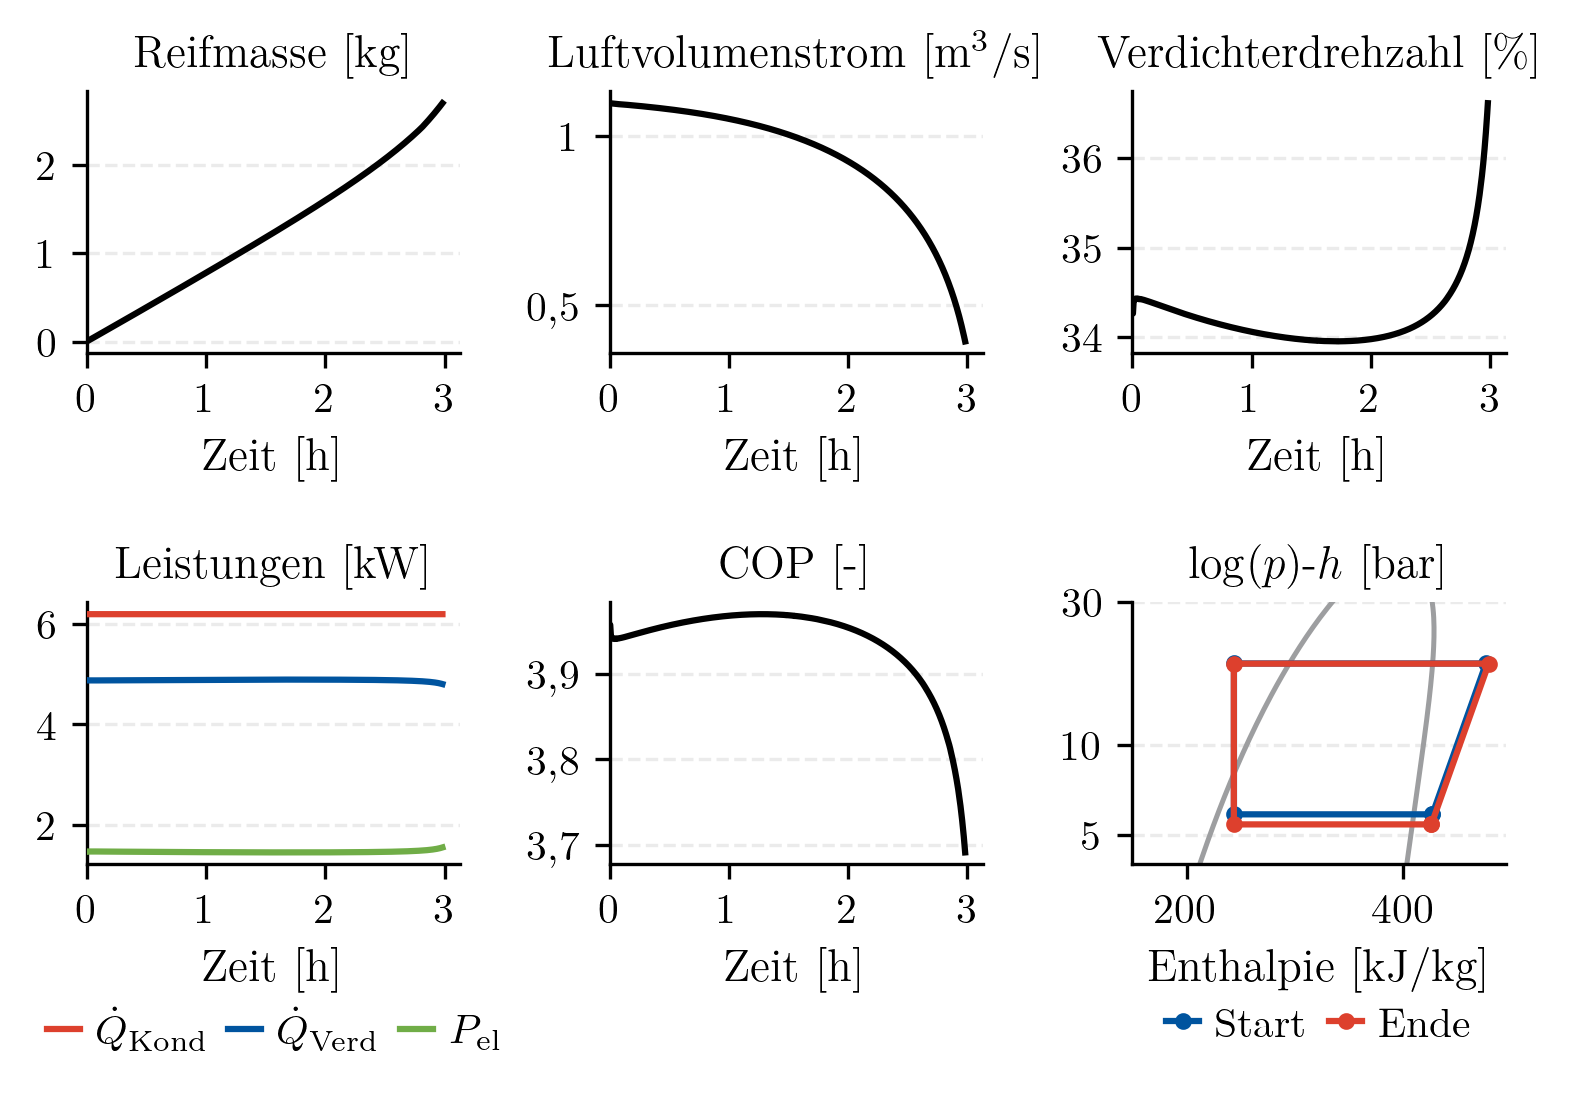

[4.88143195 4.88369176 4.88371688 ... 4.80922848 4.80738072 4.80546231]


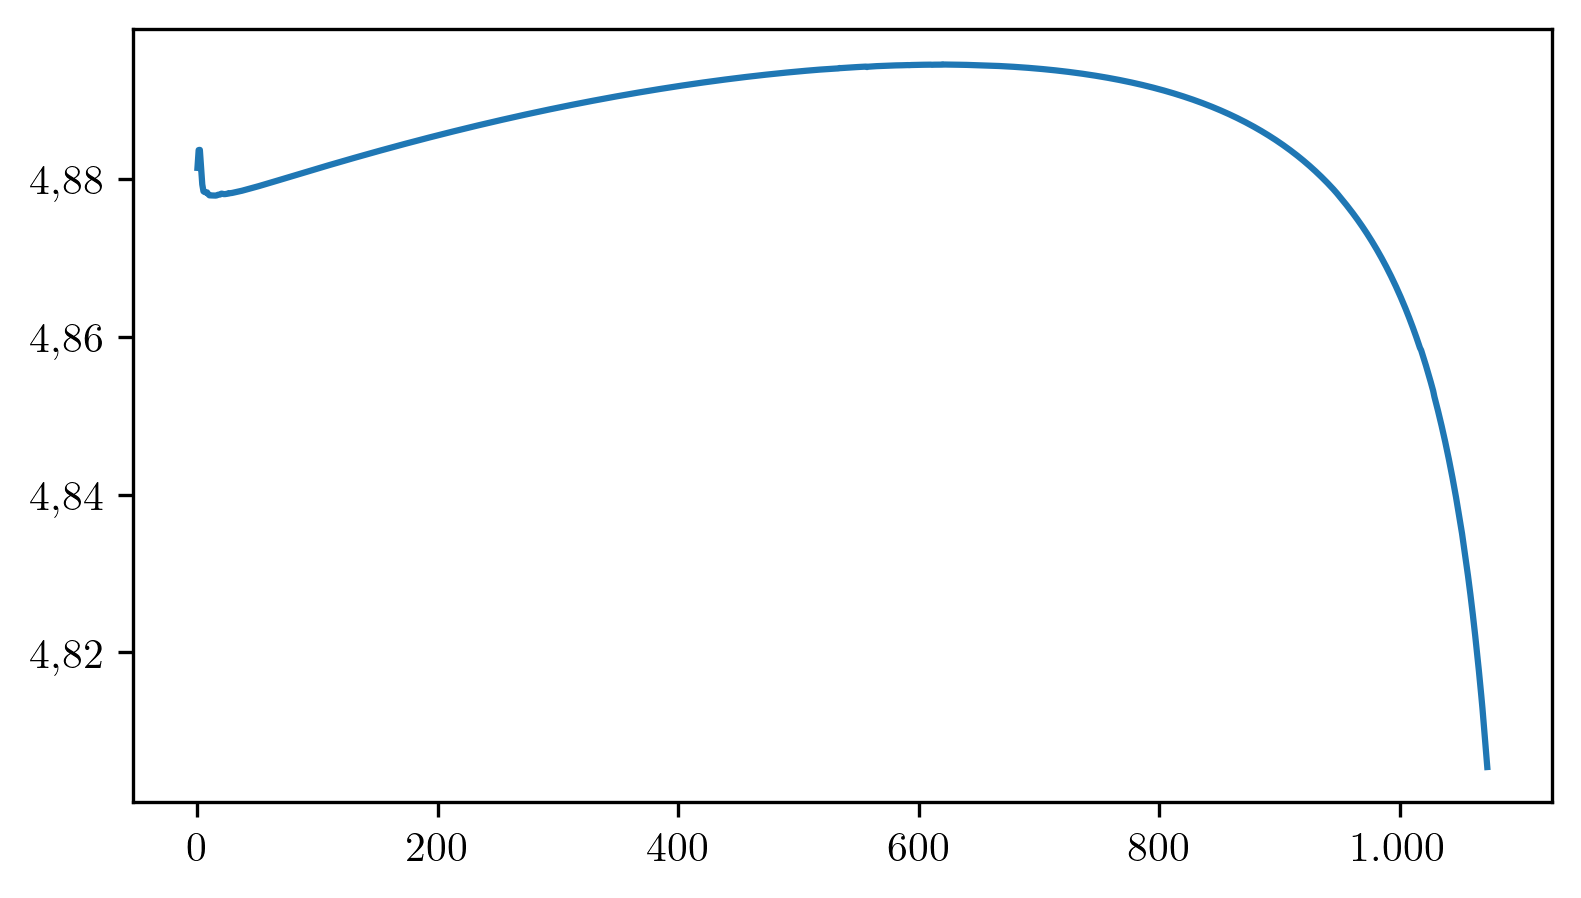

0.015562983443494827


In [24]:
import os
import pickle
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec

# =============================================================================
# 1. GLOBALE FORMATIERUNGS-EINSTELLUNGEN (STRICT GUIDELINES)
# =============================================================================
cm_to_in = 1 / 2.54
fig_width = 15.5 * cm_to_in
# Plot kompakter in der Höhe für 2 Reihen
fig_height = 8.5 * cm_to_in 

# Feste Farbpalette
COLORS = {
    "blue": "#00549F",
    "red": "#DD402D",
    "green": "#70AD47",
    "black": "black",
    "mid_grey": "#9D9EA0",
    "light_grey": "#D9D9D9"
}

# Ausgabeordner definieren
OUTPUT_DIR = r"J:\Masterarbeit_Nils_Baumeister\02_Schriftliche_Ausarbeitung\Graphiken"
os.makedirs(OUTPUT_DIR, exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (fig_width, fig_height),
    "figure.dpi": 300,
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{icomma} \usepackage{amsmath} \usepackage{lmodern}",
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.linewidth": 0.8,
    "savefig.bbox": "tight",
    "savefig.format": "pdf"
})

# =============================================================================
# 2. HELPER: DEUTSCHES ZAHLENFORMAT (Kommata statt Punkte)
# =============================================================================
def german_formatter(x, pos):
    """Wandelt Punkte in den Ticks zuverlässig in Kommata um (LaTeX-kompatibel)."""
    return f"{x:g}".replace(".", "{,}")

# =============================================================================
# 3. THESIS PLOTTING LOGIC
# =============================================================================
def plot_thesis_dashboard(results, med_prop):
    # --- Echtdaten extrahieren & in Stunden umrechnen ---
    t = np.array(results["time"]) / 60.0                # Minuten -> Stunden
    frost_mass = results["m_frost"]
    air_flow = np.array(results["v_dot_air"]) / 3600    # m^3/h -> m^3/s
    comp_speed = np.array(results["speed"]) * 100       # 0-1 -> 0-100%
    q_cond = np.array(results["Q_cond"]) / 1000.0       # W -> kW
    q_evap = np.array(results["Q_evap"]) / 1000.0       # W -> kW
    p_el = np.array(results["compressor_power"]) / 1000.0 # W -> kW
    cop = results["COP_wo_defrost"]

    # --- Plot aufbauen (Grid 2x3) ---
    fig = plt.figure()
    
    # 2 Reihen, 3 Spalten. wspace und hspace anpassen für gute Lesbarkeit
    gs = gridspec.GridSpec(2, 3, wspace=0.4, hspace=0.95)

    # Achsen initialisieren
    ax_frost = fig.add_subplot(gs[0, 0])
    ax_air   = fig.add_subplot(gs[0, 1])
    ax_speed = fig.add_subplot(gs[0, 2])
    ax_pwr   = fig.add_subplot(gs[1, 0])
    ax_cop   = fig.add_subplot(gs[1, 1])
    ax_ph    = fig.add_subplot(gs[1, 2])
    
    all_axes = [ax_frost, ax_air, ax_speed, ax_pwr, ax_cop, ax_ph]
    
    # NEU: Liste nur für die Zeit-Plots (ohne log(p)-h)
    time_axes = [ax_frost, ax_air, ax_speed, ax_pwr, ax_cop]

    # --- ZEILE 1: Reifmasse, Luftvolumen, Verdichterdrehzahl ---
    ax_frost.plot(t, frost_mass, color=COLORS["black"], linewidth=1.5, zorder=3)
    ax_frost.set_title('Reifmasse [kg]')
    ax_frost.set_xlabel('Zeit [h]')

    ax_air.plot(t, air_flow, color=COLORS["black"], linewidth=1.5, zorder=3)
    ax_air.set_title(r'Luftvolumenstrom [m$^3$/s]')
    ax_air.set_xlabel('Zeit [h]')

    ax_speed.plot(t, comp_speed, color=COLORS["black"], linewidth=1.5, zorder=3)
    ax_speed.set_title(r'Verdichterdrehzahl [\%]')
    ax_speed.set_xlabel('Zeit [h]')

    # --- ZEILE 2: Leistungen, COP, log(p)-h ---
    # Leistungen
    ax_pwr.plot(t, q_cond, color=COLORS["red"], linewidth=1.5, label=r'$\dot{Q}_\text{Kond}$', zorder=3)
    ax_pwr.plot(t, q_evap, color=COLORS["blue"], linewidth=1.5, label=r'$\dot{Q}_\text{Verd}$', zorder=3)
    ax_pwr.plot(t, p_el, color=COLORS["green"], linewidth=1.5, label=r'$P_\text{el}$', zorder=3)
    ax_pwr.set_title('Leistungen [kW]')
    ax_pwr.set_xlabel('Zeit [h]')

    
    ax_pwr.legend(
        loc='upper center', 
        bbox_to_anchor=(0.5, -0.4), 
        frameon=False, 
        ncol=3,
        columnspacing=0.5, 
        handletextpad=0.4, 
        handlelength=0.8
    )

    # COP
    ax_cop.plot(t, cop, color=COLORS["black"], linewidth=1.5, zorder=3)
    ax_cop.set_title('COP [-]')
    ax_cop.set_xlabel('Zeit [h]')

    # log(p)-h Diagramm
    if med_prop is not None:
        try:
            if hasattr(med_prop, 'get_critical_point'):
                 _, p_crit, _ = med_prop.get_critical_point()
            else:
                 p_crit = 4900000.0 
            
            p_dome_range = np.logspace(np.log10(1e5), np.log10(p_crit * 0.99), 100)
            h_liq_dome, h_vap_dome, p_dome_success = [], [], []

            for p in p_dome_range:
                try:
                    hl = med_prop.calc_state("PQ", p, 0.0).h / 1000.0
                    hv = med_prop.calc_state("PQ", p, 1.0).h / 1000.0
                    h_liq_dome.append(hl)
                    h_vap_dome.append(hv)
                    p_dome_success.append(p)
                except: pass

            h_dome_full = np.concatenate([h_liq_dome, h_vap_dome[::-1]])
            p_dome_full = np.concatenate([p_dome_success, p_dome_success[::-1]])
            
            ax_ph.plot(h_dome_full, p_dome_full / 1e5, color=COLORS["mid_grey"], linewidth=1.2, zorder=2)
        except Exception as e:
            print(f"Could not plot saturation dome: {e}")

    # Echte Zyklen Plotten
    cycles = results.get("cycles", [])
    if cycles:
        cycle_start = cycles[0]
        cycle_end = cycles[-1]
        
        ax_ph.plot(np.array(cycle_start["h"])/1000.0, np.array(cycle_start["p"])/1e5, 
                   color=COLORS["blue"], marker='.', markersize=6, linewidth=1.5, label='Start', zorder=3)
        ax_ph.plot(np.array(cycle_end["h"])/1000.0, np.array(cycle_end["p"])/1e5, 
                   color=COLORS["red"], marker='.', markersize=6, linewidth=1.5, label='Ende', zorder=3)
        
    ax_ph.set_yscale('log')
    ax_ph.set_ylim(4, 30)
    custom_ticks = [5, 10, 30] 
    ax_ph.set_yticks(custom_ticks)
    ax_ph.set_yticks([], minor=True)
    
    ax_ph.set_title(r'$\log(p)$-$h$ [bar]')
    ax_ph.set_xlabel('Enthalpie [kJ/kg]')
    ax_ph.legend(
        loc='upper center', 
        bbox_to_anchor=(0.5, -0.4), 
        ncol=2, 
        frameon=False,
        columnspacing=0.5, 
        handletextpad=0.4, 
        handlelength=0.8
    )

    # --- Kosmetik & Layout strikt nach Scientific-Style anwenden ---
    # 1. Spezifische X-Ticks NUR für die Zeit-Plots anwenden
    for ax in time_axes:
        ax.set_xlim(0, None) 
        ax.set_xticks([0, 1, 2, 3])

    # 2. Globale Anpassungen für ALLE Achsen
    for ax in all_axes:
        # Subtiles Grid, nur Y-Achse
        ax.grid(axis='y', linestyle='--', alpha=0.5, color=COLORS["light_grey"], zorder=0)
        # Keine Achsenlinien oben und rechts
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        # Lokalisierung der Achsen-Ticks (Deutsches Komma)
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(german_formatter))
        ax.yaxis.set_major_formatter(ticker.FuncFormatter(german_formatter))

    # Speichern des Plots direkt im Zielverzeichnis
    output_path = os.path.join(OUTPUT_DIR, "6_Verdampfer_Sim_Ergebnis.pdf")
    plt.savefig(output_path, format='pdf', bbox_inches='tight')
    plt.show()

# =============================================================================
# 4. DATA LOADING & EXECUTION
# =============================================================================
from vclibpy.media import RefProp
import math

REFPROP_DIR = Path(r"C:\Program Files (x86)\REFPROP")
REFPROP_DLL = REFPROP_DIR / "REFPRP64.DLL"
os.environ["RPPREFIX"] = str(REFPROP_DIR)

med_prop = RefProp(
    fluid_name="R134a",
    dll_path=str(REFPROP_DLL), 
    ref_prop_path=str(REFPROP_DIR),
    copy_dll=False
)

file_path = "simulation_data/final/06_grid_horst_final.pkl"

# --- ZIEL-PARAMETER DEFINIEREN ---
TARGET_APP = 'Low'
TARGET_PT = 'B'
TARGET_PITCH_M = 1.75 / 1000.0 

if os.path.exists(file_path):
    with open(file_path, "rb") as f:
        all_data = pickle.load(f)
        all_runs_data = all_data["runs_data"]

    target_result = None
    
    # --- DYNAMISCHE SUCHE NACH DEM RICHTIGEN DATENSATZ ---
    for run in all_runs_data:
        if "metadata" not in run or "error" in run:
            continue
            
        meta = run["metadata"]
        context = meta.get("norm_context", {})
        inputs = meta.get("inputs", {})

        app = context.get("application")
        pt = context.get("test_point")
        pitch = inputs.get("pitch", 0)

        if app == TARGET_APP and pt == TARGET_PT and math.isclose(pitch, TARGET_PITCH_M, abs_tol=1e-5):
            target_result = run
            break

    # --- PLOT AUFRUFEN ODER FEHLER MELDEN ---
    if target_result is not None:
        print(f"Datensatz erfolgreich gefunden: {TARGET_APP}, {TARGET_PT} bei {TARGET_PITCH_M*1000} mm.")
        plot_thesis_dashboard(target_result, med_prop)
    else:
        print(f"FEHLER: Kein Datensatz für App={TARGET_APP}, Point={TARGET_PT} und Pitch={TARGET_PITCH_M*1000}mm gefunden!")
        
else:
    print(f"Datei nicht gefunden: {file_path}")

# Tradeoff Big Plot

Verdichter-Änderungen: [-0.50168813 -3.50076704 -4.60699313 -3.770919   -2.63803045 -1.45447573
  0.          1.63931756]
Ventilator-Änderungen: [ 0.6317334   0.40934175  0.19224121  0.0858816   0.04341182  0.01573336
  0.         -0.02736363]
Abtau-Änderungen: [-1.47245252 -2.0968137  -1.83184276 -1.39462043 -0.9205027  -0.43230133
  0.          0.06776131]


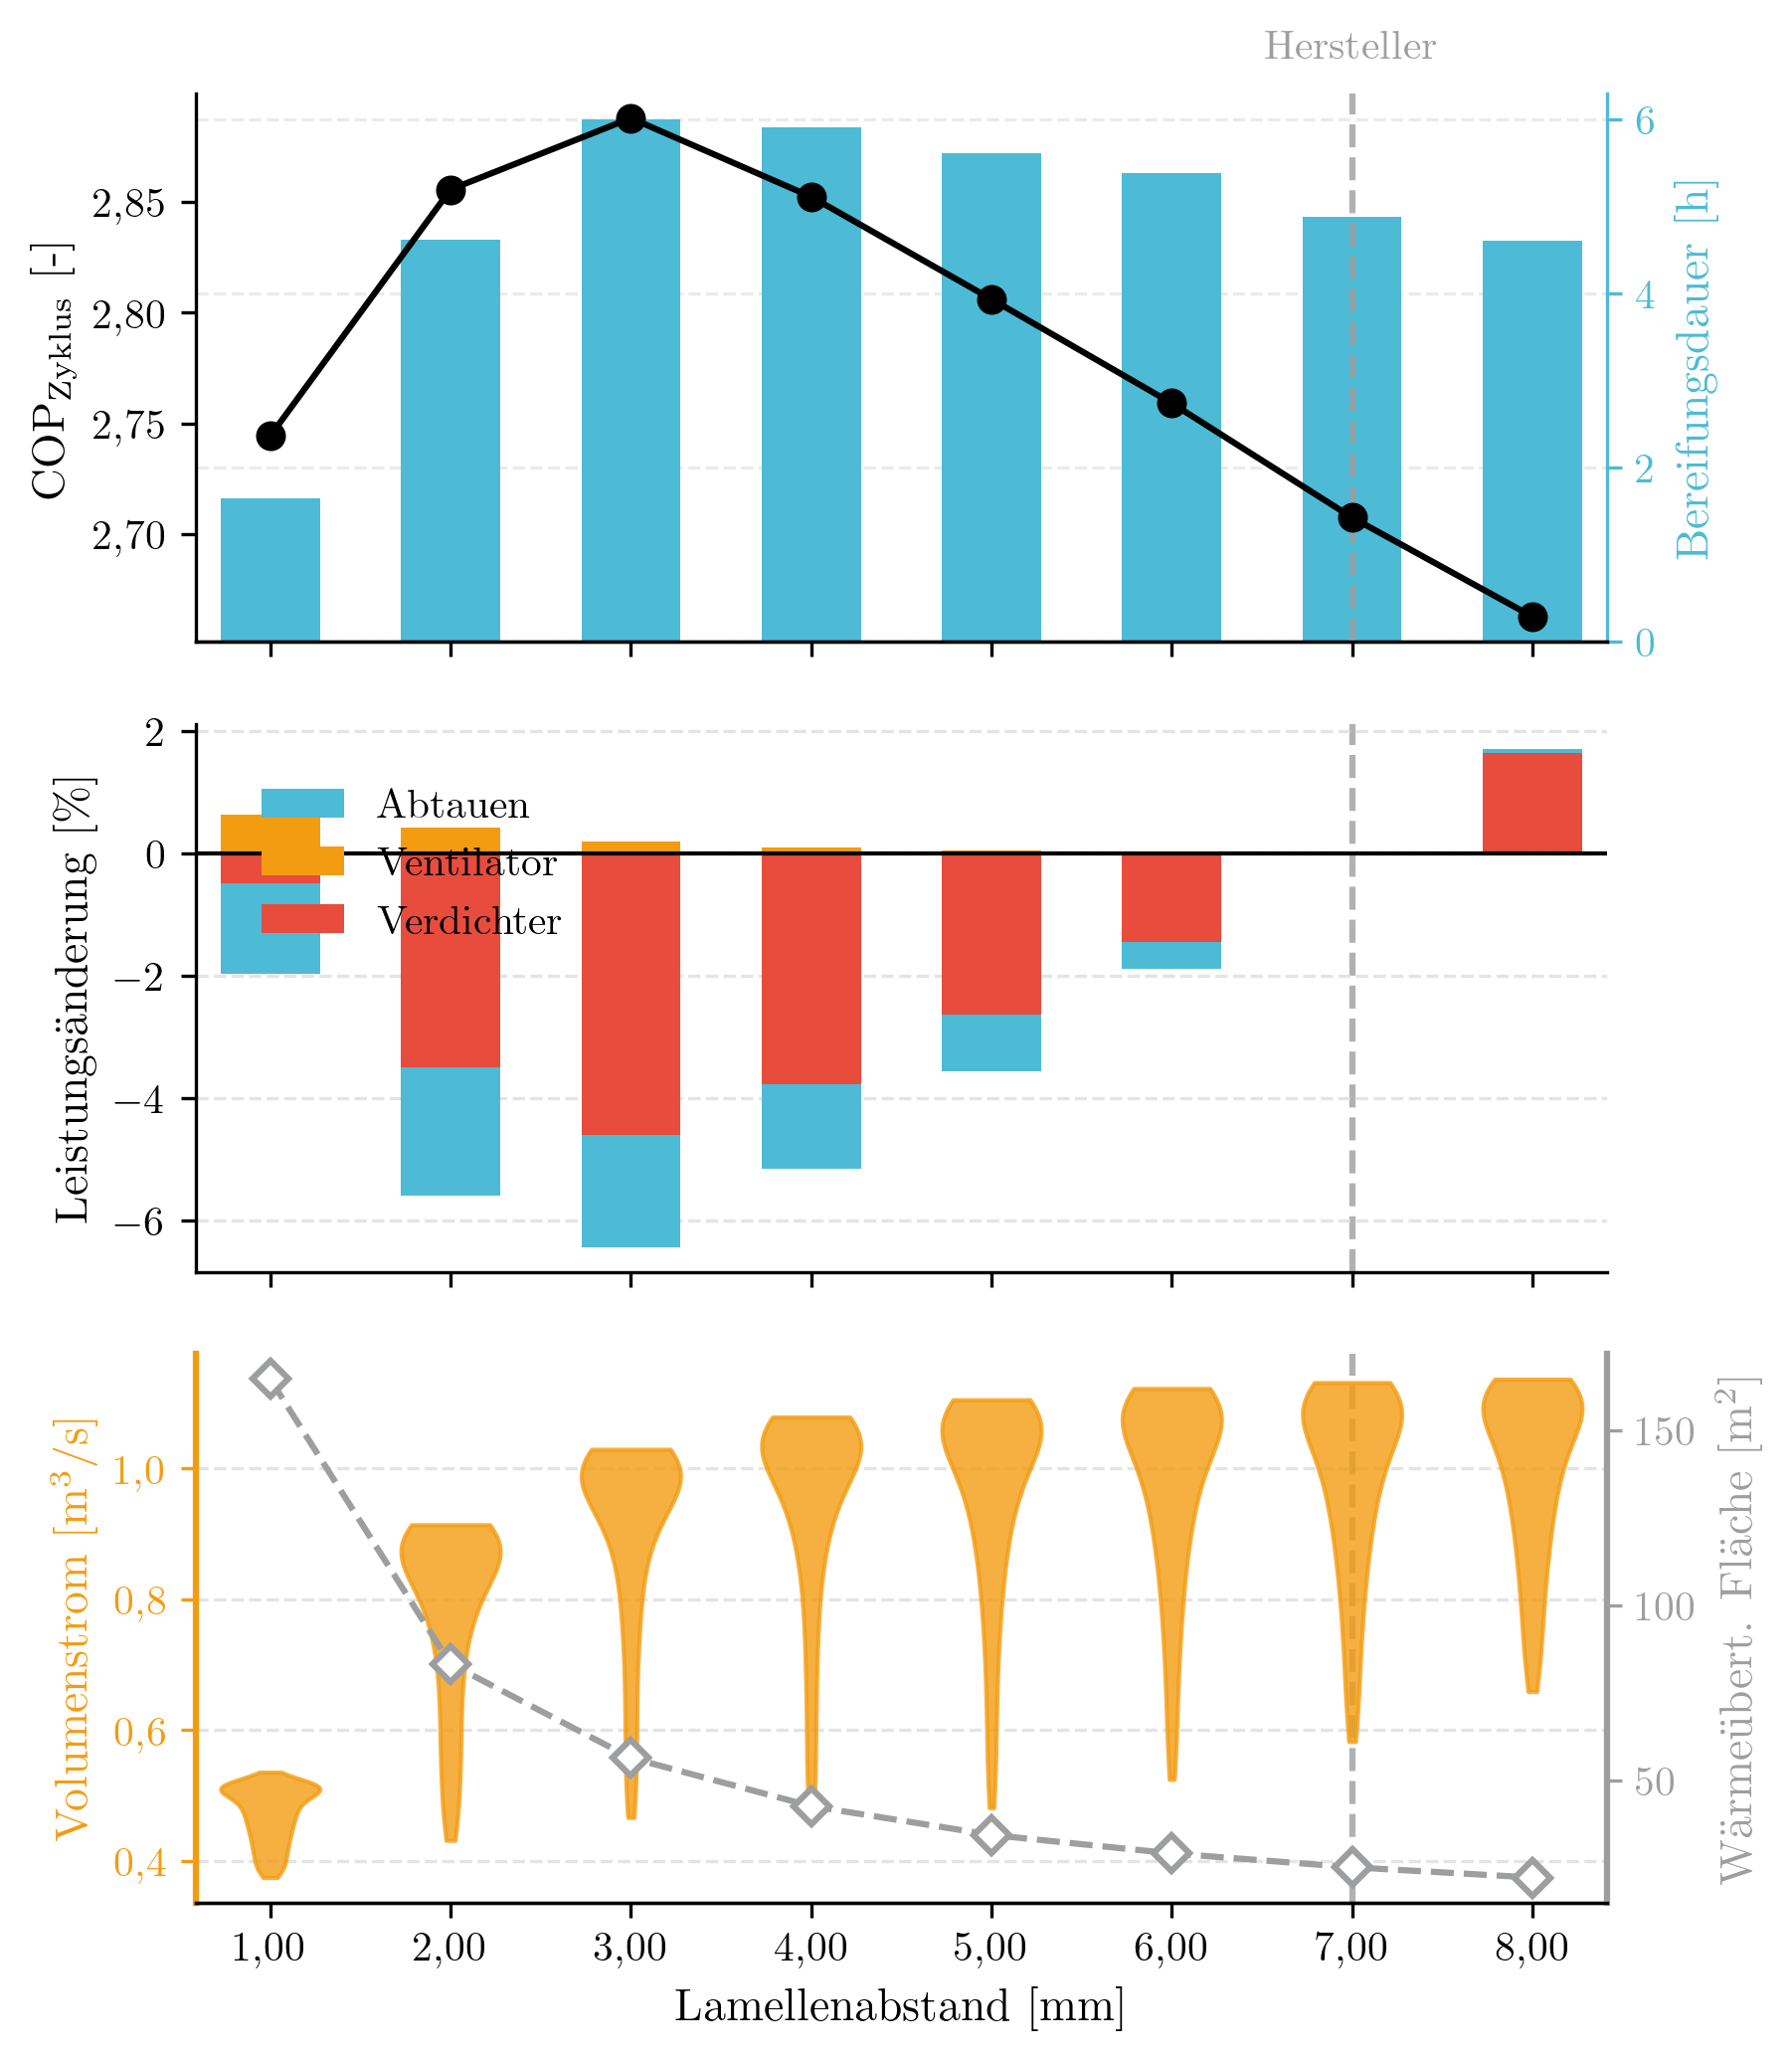

In [54]:
import os
import pickle
import locale
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# =============================================================================
# LOCALE & GLOBALE PLOT-EINSTELLUNGEN FÜR DIE MASTERARBEIT
# =============================================================================

try:
    locale.setlocale(locale.LC_NUMERIC, "de_DE.UTF-8")
except locale.Error:
    try:
        locale.setlocale(locale.LC_NUMERIC, "de_DE")
    except locale.Error:
        pass

def set_plot_style():
    """
    Setzt die globalen, publikationsfähigen Matplotlib-Parameter für die Masterarbeit.
    """
    cm_to_inch = 1 / 2.54
    width_cm = 15.5
    height_cm = 20.0  # Beibehalten, da 3 Subplots Platz brauchen

    plt.rcParams.update({
        "figure.figsize": (width_cm * cm_to_inch, height_cm * cm_to_inch),
        "figure.dpi": 300,
        "text.usetex": True,
        "text.latex.preamble": r"\usepackage{icomma} \usepackage{amsmath}",
        "font.family": "serif",
        "font.size": 11,
        "axes.labelsize": 11,
        "legend.fontsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "axes.formatter.use_locale": True,
        "axes.linewidth": 0.8,
        "grid.color": "#D9D9D9",
        "grid.linestyle": "--",
        "grid.alpha": 0.7,
        "legend.frameon": False,
        "savefig.bbox": "tight",
        "savefig.format": "pdf"
    })

    # CI Farben plus die gewünschten Sonderfarben
    return {
        "blue": "#00549F",
        "dark_grey": "#4E4F50",
        "mid_grey": "#9D9EA0",
        "light_grey": "#D9D9D9",
        # Neue explizite Leistungsklassen-Farben
        "abtauen": "#4DBBD5",    # Blau
        "luefter": "#F39C12",    # Orange
        "verdichter": "#E74C3C"  # Rot
    }

def main():
    colors = set_plot_style()
    
    # =============================================================================
    # 1. DATEN LADEN UND STRIKT FILTERN
    # =============================================================================
    filename = "simulation_data/final/06_grid_horst_final.pkl"
    MANUFACTURER_PITCH_MM = 1.5
    # target_app = 'Low'
    # target_pt  = 'B'

    # filename = "simulation_data/final/06_grid_abt_final.pkl"
    # filename = "simulation_data/final/abt_low_B_15kW_time.pkl"
    filename = "simulation_data/grand_scop_simulation_results_abt_1.pkl"
    MANUFACTURER_PITCH_MM = 7.0

    target_app = 'Low'
    target_pt  = 'E'


    try:
        with open(filename, "rb") as f:
            all_data = pickle.load(f)
            all_runs_data = all_data["runs_data"]
    except FileNotFoundError:
        print(f"Error: Datei '{filename}' nicht gefunden.")
        return
    

    
    extracted_data = {}

    for run in all_runs_data:
        if "metadata" not in run or "error" in run:
            continue
            
        meta = run["metadata"]
        context = meta.get("norm_context", {})

        if context.get("application") == target_app and context.get("test_point") == target_pt:
            inputs = meta.get("inputs", {})
            pitch_mm = inputs.get("pitch", 0) * 1000.0
            
            v_dot = np.array(run.get("v_dot_air", []), dtype=float)
            v_dot = v_dot[~np.isnan(v_dot)] / 3600.0  
            
            if len(v_dot) > 1000:
                v_dot = v_dot[::10]
            
            area = np.array(run.get("total_frost_area", []), dtype=float)
            area = area[~np.isnan(area)]
            
            q_dot = inputs.get("actual_q_dot", 1.0)
            
            if q_dot and q_dot > 0:
                extracted_data[pitch_mm] = {
                    "v_dot": v_dot,
                    "area_mean": np.mean(area) if len(area) > 0 else 0,
                    "cop": inputs.get("cycle-COP", 0),
                    "duration_h": inputs.get("total_duration_min", 0) / 60.0,
                    "p_comp_norm": inputs.get("actual_p_comp", 0) / q_dot,
                    "p_fan_norm": inputs.get("actual_p_fan", 0) / q_dot,
                    "p_defrost_norm": inputs.get("actual_p_defrost", 0) / q_dot
                }

    if not extracted_data:
        print(f"Keine Daten für Application '{target_app}' und Point '{target_pt}' gefunden.")
        return

    sorted_pitches = sorted(extracted_data.keys())
    
    if MANUFACTURER_PITCH_MM in extracted_data:
        base_data = extracted_data[MANUFACTURER_PITCH_MM]
    else:
        base_data = extracted_data[sorted_pitches[0]]

    total_baseline_p = base_data["p_comp_norm"] + base_data["p_fan_norm"] + base_data["p_defrost_norm"]

    cops = [extracted_data[p]["cop"] for p in sorted_pitches]
    durations = [extracted_data[p]["duration_h"] for p in sorted_pitches]
    
    d_comp = [(extracted_data[p]["p_comp_norm"] - base_data["p_comp_norm"]) / total_baseline_p * 100 for p in sorted_pitches]
    d_fan = [(extracted_data[p]["p_fan_norm"] - base_data["p_fan_norm"]) / total_baseline_p * 100 for p in sorted_pitches]
    d_defrost = [(extracted_data[p]["p_defrost_norm"] - base_data["p_defrost_norm"]) / total_baseline_p * 100 for p in sorted_pitches]
    
    violin_data_v = [extracted_data[p]["v_dot"] for p in sorted_pitches]
    means_area = [extracted_data[p]["area_mean"] for p in sorted_pitches]


    # =============================================================================
    # 2. PLOTTING (3-Panel Layout)
    # =============================================================================
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, gridspec_kw={'hspace': 0.15})
    
    ax1_twin = ax1.twinx()
    ax3_twin = ax3.twinx()

    bar_width = np.min(np.diff(sorted_pitches)) * 0.55 if len(sorted_pitches) > 1 else 0.3

    # -------------------------------------------------------------------------
    # PANEL 1: COP (Vorne) & Bereifungsdauer (Mitte) & Raster (Hinten)
    # -------------------------------------------------------------------------
    color_cop = "black"
    color_dur = colors["abtauen"] 

    # 1. Balken auf der Twin-Achse (Hintergrund-Achse für Daten)
    ax1_twin.bar(sorted_pitches, durations, width=bar_width, color=color_dur, alpha=1.0, zorder=2)
    ax1_twin.set_ylabel("Bereifungsdauer [h]", color=color_dur)
    ax1_twin.tick_params(axis='y', colors=color_dur)
    ax1_twin.spines['right'].set_color(color_dur)

    # Raster auf die hintere Achse schieben, damit es hinter den Balken liegt
    ax1_twin.grid(axis='y', linestyle='--', linewidth=0.8, alpha=0.5, zorder=0)
    ax1_twin.set_axisbelow(True)

    # 2. COP-Linie auf der Hauptachse (wird nach vorne geholt)
    ax1.plot(sorted_pitches, cops, color=color_cop, linestyle='-', linewidth=1.5, 
             marker='o', markersize=6, markerfacecolor=color_cop, markeredgewidth=1.2, zorder=10)
    ax1.set_ylabel(r"$\text{COP}_\text{Zyklus}$ [-]", color=color_cop)
    ax1.tick_params(axis='y', colors=color_cop)
    ax1.grid(False) # WICHTIG: Raster auf der vorderen Achse ausschalten

    # 3. Layer-Tausch: ax1 (Linie) vor ax1_twin (Balken)
    ax1.set_zorder(ax1_twin.get_zorder() + 1)
    ax1.patch.set_visible(False) # Hintergrund transparent machen

    # -------------------------------------------------------------------------
    # PANEL 2: LEISTUNGSÄNDERUNG (Mit CI-Farben gestapelt)
    # -------------------------------------------------------------------------
    pos_bottom = np.zeros(len(sorted_pitches))
    neg_bottom = np.zeros(len(sorted_pitches))

    y_comp = np.array(d_comp)
    y_fan = np.array(d_fan)
    y_defrost = np.array(d_defrost)

    # Verdichter (Rot)
    bottoms = np.where(y_comp >= 0, pos_bottom, neg_bottom)
    ax2.bar(sorted_pitches, y_comp, bottom=bottoms, width=bar_width, color=colors["verdichter"], label="Verdichter", zorder=3)
    pos_bottom += np.maximum(y_comp, 0)
    neg_bottom += np.minimum(y_comp, 0)
    print("Verdichter-Änderungen:", y_comp)

    # Ventilator/Lüfter (Orange)
    bottoms = np.where(y_fan >= 0, pos_bottom, neg_bottom)
    ax2.bar(sorted_pitches, y_fan, bottom=bottoms, width=bar_width, color=colors["luefter"], label="Ventilator", zorder=3)
    pos_bottom += np.maximum(y_fan, 0)
    neg_bottom += np.minimum(y_fan, 0)
    print("Ventilator-Änderungen:", y_fan)

    # Abtauung (Blau)
    bottoms = np.where(y_defrost >= 0, pos_bottom, neg_bottom)
    ax2.bar(sorted_pitches, y_defrost, bottom=bottoms, width=bar_width, color=colors["abtauen"], label="Abtauen", zorder=3)
    ax2.axhline(0, color='black', linewidth=1, zorder=4)
    ax2.set_ylabel(r"Leistungsänderung [\%]")
    ax2.grid(axis='y', zorder=0)
    print("Abtau-Änderungen:", y_defrost)


    # -------------------------------------------------------------------------
    # PANEL 3: VOLUMENSTROM & FLÄCHE
    # -------------------------------------------------------------------------
    color_v = colors["luefter"]  # Farbe wie Lüfter
    color_area = colors["mid_grey"]

    parts_v = ax3.violinplot(violin_data_v, positions=sorted_pitches, widths=bar_width,
                             showmeans=False, showmedians=False, showextrema=False)
    for pc in parts_v['bodies']:
        pc.set_facecolor(color_v)
        pc.set_edgecolor(color_v)
        pc.set_alpha(0.8)
        pc.set_zorder(2)

    ax3.set_xlabel("Lamellenabstand [mm]")
    ax3.set_ylabel(r"Volumenstrom [m$^3$/s]", color=color_v)
    ax3.tick_params(axis='y', colors=color_v)
    ax3.spines['left'].set_color(color_v)
    ax3.spines['left'].set_linewidth(1.5)
    
    ax3_twin.plot(sorted_pitches, means_area, color=color_area, linestyle='--', linewidth=1.5, 
                  marker='D', markersize=6, markerfacecolor='white', markeredgewidth=1.5, zorder=5)
    ax3_twin.set_ylabel(r"Wärmeübert. Fläche [m$^2]$", color=color_area)
    ax3_twin.tick_params(axis='y', colors=color_area)
    ax3_twin.spines['right'].set_color(color_area)
    ax3_twin.spines['right'].set_linewidth(1.5)

    ax3.grid(axis='y', zorder=0)

    # -------------------------------------------------------------------------
    # GLOBALE FORMATIERUNG & LINIEN
    # -------------------------------------------------------------------------
    color_manuf = colors["mid_grey"]
    
    for ax in [ax1, ax2, ax3]:
        ax.axvline(x=MANUFACTURER_PITCH_MM, color=color_manuf, linestyle='--', linewidth=1.5, alpha=0.8, zorder=1)

    # Hersteller-Label mit relativen Koordinaten um Clipping zu vermeiden
    ax1.text(MANUFACTURER_PITCH_MM, 1.05, 'Hersteller', 
             color=color_manuf, fontsize=10, 
             ha='center', va='bottom', transform=ax1.get_xaxis_transform(), clip_on=False)

    # Subplot Spines bereinigen
    for ax in [ax1, ax1_twin, ax2, ax3, ax3_twin]:
        ax.spines['top'].set_visible(False)
        if ax not in [ax1_twin, ax3_twin]:
            ax.spines['right'].set_visible(False)
            
    # --- FIX FÜR DEN SCHWARZEN STREIFEN AUF DER LINKEN ACHSE ---
    ax1_twin.spines['left'].set_visible(False)
    ax3_twin.spines['left'].set_visible(False)

    pad_x = bar_width * 0.75
    ax3.set_xlim(min(sorted_pitches) - pad_x, max(sorted_pitches) + pad_x)
    
    # MANUELLE DEZIMALKORREKTUR FÜR DIE X-ACHSE (Punkt zu Komma)
    plt.xticks(sorted_pitches, [f"{p:.2f}".replace('.', ',') for p in sorted_pitches])

    # -------------------------------------------------------------------------
    # LEGENDEN & EXPORT
    # -------------------------------------------------------------------------
    handles_p, labels_p = ax2.get_legend_handles_labels()
    
    # LEGENDE SCHMAL, OBEN LINKS IM PLOT PLATZIERT
    ax2.legend(reversed(handles_p), reversed(labels_p), 
               loc='upper left', 
               bbox_to_anchor=(0.02, 0.95), # Leicht nach rechts (0.02) und unten (0.95) eingerückt
               ncol=1, frameon=False)

    # output_dir = r"J:\Masterarbeit_Nils_Baumeister\02_Schriftliche_Ausarbeitung\Graphiken"
    # os.makedirs(output_dir, exist_ok=True)
    # output_path = os.path.join(output_dir, "6_wp_optimum_detailed.pdf")
    
    # plt.savefig(output_path, bbox_inches="tight")
    plt.show()
    # print(f"Plot erfolgreich generiert und abgelegt unter: {output_path}")

if __name__ == "__main__":
    main()

Plot erfolgreich generiert und abgelegt unter: J:\Masterarbeit_Nils_Baumeister\02_Schriftliche_Ausarbeitung\Graphiken\6_dauer_optimum_minus_7.pdf


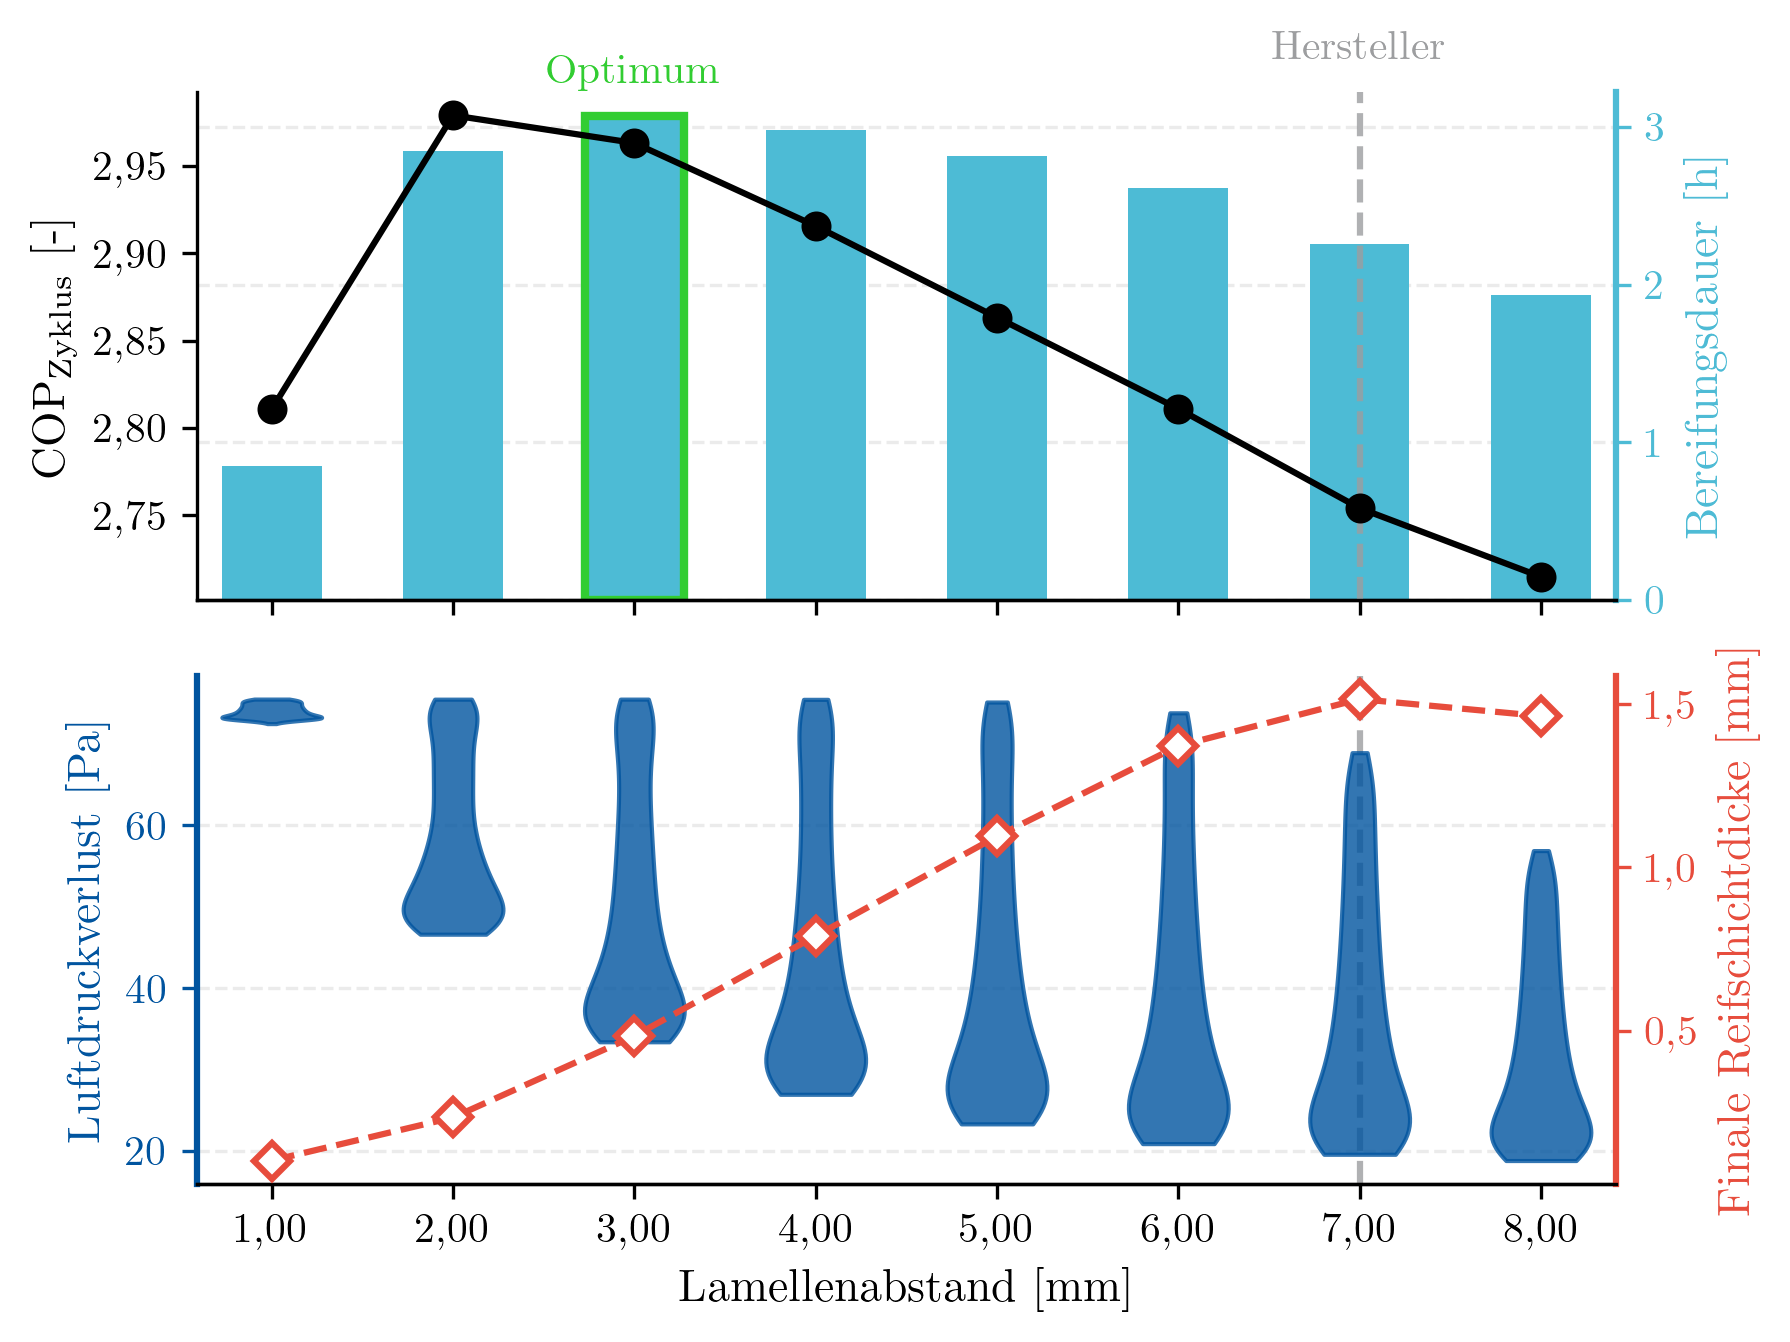

In [44]:
import os
import pickle
import locale
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# =============================================================================
# LOCALE & GLOBALE PLOT-EINSTELLUNGEN
# =============================================================================
try:
    locale.setlocale(locale.LC_NUMERIC, "de_DE.UTF-8")
except locale.Error:
    try:
        locale.setlocale(locale.LC_NUMERIC, "de_DE")
    except locale.Error:
        pass

def set_plot_style():
    cm_to_inch = 1 / 2.54
    width_cm = 15.5
    height_cm = 12.0  # Platz für 2 Panels

    plt.rcParams.update({
        "figure.figsize": (width_cm * cm_to_inch, height_cm * cm_to_inch),
        "figure.dpi": 300,
        "text.usetex": True,
        "text.latex.preamble": r"\usepackage{icomma} \usepackage{amsmath}",
        "font.family": "serif",
        "font.size": 11,
        "axes.labelsize": 11,
        "legend.fontsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "axes.formatter.use_locale": True,
        "axes.linewidth": 0.8,
        "grid.color": "#D9D9D9",
        "grid.linestyle": "--",
        "grid.alpha": 0.7,
        "legend.frameon": False,
        "savefig.bbox": "tight",
        "savefig.format": "pdf"
    })

    return {
        "blue": "#00549F",
        "dark_grey": "#4E4F50",
        "mid_grey": "#9D9EA0",
        "light_grey": "#D9D9D9",
        "abtauen": "#4DBBD5",    
        "luefter": "#F39C12",    
        "verdichter": "#E74C3C"  
    }

def main():
    colors = set_plot_style()
    
    # =============================================================================
    # 1. DATEN LADEN UND EXTRAHIEREN
    # =============================================================================
    filename = "simulation_data/final/abt_low_B_15kW_time.pkl"
    target_app = 'Low'
    target_pt  = 'B'

    filename = "simulation_data/final/abt_low_A_11-5kW_time.pkl"
    target_app = 'Low'
    target_pt  = 'A'

    MANUFACTURER_PITCH_MM = 7.0



    try:
        with open(filename, "rb") as f:
            all_data = pickle.load(f)
            all_runs_data = all_data["runs_data"]
    except FileNotFoundError:
        print(f"Error: Datei '{filename}' nicht gefunden.")
        return
    
    extracted_data = {}

    for run in all_runs_data:
        if "metadata" not in run or "error" in run:
            continue
            
        meta = run["metadata"]
        context = meta.get("norm_context", {})

        if context.get("application") == target_app and context.get("test_point") == target_pt:
            inputs = meta.get("inputs", {})
            pitch_m = inputs.get("pitch", 0)
            pitch_mm = pitch_m * 1000.0
            
            time_arr = np.array(run.get("time", []), dtype=float)
            dp_air = np.array(run.get("dp_air", []), dtype=float)
            space_m = np.array(run.get("space_between_frost", []), dtype=float)
            
            valid_idx = ~np.isnan(dp_air) & ~np.isnan(space_m)
            time_arr = time_arr[valid_idx]
            dp_air = dp_air[valid_idx]
            space_m = space_m[valid_idx]
            
            if len(dp_air) > 0:
                thickness_mm = (pitch_m - space_m) / 2.0 * 1000.0
                
                extracted_data[pitch_mm] = {
                    "final_time": time_arr[-1],
                    "dp_air_full": dp_air,
                    "final_thickness": thickness_mm[-1],
                    "cop": inputs.get("cycle-COP", 0)
                }

    if not extracted_data:
        print(f"Keine Daten für Application '{target_app}' und Point '{target_pt}' gefunden.")
        return

    sorted_pitches = sorted(extracted_data.keys())
    
    x_pitches = np.array(sorted_pitches)
    y_time = np.array([extracted_data[p]["final_time"] for p in sorted_pitches]) / 60.0
    y_thick = np.array([extracted_data[p]["final_thickness"] for p in sorted_pitches])
    y_cop = np.array([extracted_data[p]["cop"] for p in sorted_pitches]) 
    violin_dp_data = [extracted_data[p]["dp_air_full"] for p in sorted_pitches]

    bar_width = np.min(np.diff(sorted_pitches)) * 0.55 if len(sorted_pitches) > 1 else 0.3

    # =============================================================================
    # 2. PLOTTING (2-Panel Layout)
    # =============================================================================
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, gridspec_kw={'hspace': 0.15})
    
    # Twin-Achsen für beide Panels vorbereiten
    ax1_twin = ax1.twinx()
    ax2_twin = ax2.twinx()
    
    # ---------------------------------------------------------
    # PANEL 1 (Oben): COP vs. Bereifungsdauer (mit Optimum)
    # ---------------------------------------------------------
    color_cop = "black"
    color_dur = colors["abtauen"] 
    
    # 1. Balken für Bereifungsdauer auf der Twin-Achse (Hintergrund)
    bars = ax1_twin.bar(x_pitches, y_time, width=bar_width, color=color_dur, alpha=1.0, zorder=2)
    ax1_twin.set_ylabel("Bereifungsdauer [h]", color=color_dur)
    
    ax1_twin.tick_params(axis='y', colors=color_dur)
    ax1_twin.spines['right'].set_color(color_dur)
    ax1_twin.spines['right'].set_linewidth(1.5)
    
    ax1_twin.grid(axis='y', linestyle='--', linewidth=0.8, alpha=0.5, zorder=0)
    ax1_twin.set_axisbelow(True)

    # Optimum markieren (Rote Umrandung für den höchsten Balken auf ax1_twin)
    max_idx = np.argmax(y_time)
    bars[max_idx].set_edgecolor("limegreen")
    bars[max_idx].set_linewidth(2.0)
    
    ax1_twin.annotate('Optimum', xy=(x_pitches[max_idx], y_time[max_idx]), 
                      xytext=(0, 8), textcoords='offset points', ha='center', color="limegreen",
                      fontsize=10, fontweight='bold')

    # 2. COP-Linie auf der Hauptachse (Vordergrund)
    ax1.plot(x_pitches, y_cop, color=color_cop, linestyle='-', linewidth=1.5, 
             marker='o', markersize=6, markerfacecolor=color_cop, markeredgewidth=1.2, zorder=10)
    ax1.set_ylabel(r"$\text{COP}_\text{Zyklus}$ [-]", color=color_cop)
    ax1.tick_params(axis='y', colors=color_cop)
    ax1.grid(False) # Raster auf der vorderen Achse aus

    # 3. Layer-Tausch: ax1 (Linie) vor ax1_twin (Balken)
    ax1.set_zorder(ax1_twin.get_zorder() + 1)
    ax1.patch.set_visible(False)

    # ---------------------------------------------------------
    # PANEL 2 (Unten): Trade-Off (Violine vs. Linie) - UNVERÄNDERT
    # ---------------------------------------------------------
    color_dp = colors["blue"]
    color_thick = colors["verdichter"]
    
    # 1. Violine für Druckverlust (Primärachse)
    parts = ax2.violinplot(violin_dp_data, positions=x_pitches, widths=bar_width,
                           showmeans=False, showmedians=False, showextrema=False)
    
    for pc in parts['bodies']:
        pc.set_facecolor(color_dp)
        pc.set_edgecolor(color_dp)
        pc.set_alpha(0.8)  
        pc.set_zorder(2)

    ax2.set_ylabel("Luftdruckverlust [Pa]", color=color_dp)
    ax2.tick_params(axis='y', colors=color_dp)
    ax2.spines['left'].set_color(color_dp)
    ax2.spines['left'].set_linewidth(1.5)
    
    ax2.grid(axis='y', linestyle='--', linewidth=0.8, alpha=0.5, zorder=0)
    ax2.set_axisbelow(True)
    
    # 2. Kurve für finale Reifdicke (Sekundärachse)
    ax2_twin.plot(x_pitches, y_thick, color=color_thick, linestyle='--', linewidth=1.5, 
                  marker='D', markersize=6, markerfacecolor='white', markeredgewidth=1.5, zorder=5)
    
    ax2_twin.set_ylabel("Finale Reifschichtdicke [mm]", color=color_thick)
    ax2_twin.tick_params(axis='y', colors=color_thick)
    ax2_twin.spines['right'].set_color(color_thick)
    ax2_twin.spines['right'].set_linewidth(1.5)

    ax2.set_xlabel("Lamellenabstand [mm]")
    
    # -------------------------------------------------------------------------
    # GLOBALE FORMATIERUNG & LINIEN
    # -------------------------------------------------------------------------
    color_manuf = colors["mid_grey"]
    
    # Hersteller-Referenz einziehen
    for ax in [ax1, ax2]:
        ax.axvline(x=MANUFACTURER_PITCH_MM, color=color_manuf, linestyle='--', linewidth=1.5, alpha=0.8, zorder=1)

    ax1.text(MANUFACTURER_PITCH_MM, 1.05, 'Hersteller', 
             color=color_manuf, fontsize=10, 
             ha='center', va='bottom', transform=ax1.get_xaxis_transform(), clip_on=False)

    # Subplot Spines bereinigen (angepasst für ax1_twin)
    for ax in [ax1, ax1_twin, ax2, ax2_twin]:
        ax.spines['top'].set_visible(False)
        if ax not in [ax1_twin, ax2_twin]:
            ax.spines['right'].set_visible(False)
            
    # Fix für schwarzen Streifen auf linken Twin-Achsen
    ax1_twin.spines['left'].set_visible(False)
    ax2_twin.spines['left'].set_visible(False)

    pad_x = bar_width * 0.75
    ax2.set_xlim(min(x_pitches) - pad_x, max(x_pitches) + pad_x)

    plt.xticks(x_pitches, [f"{p:.2f}".replace('.', ',') for p in x_pitches])

    # -------------------------------------------------------------------------
    # SPEICHERN & EXPORT
    # -------------------------------------------------------------------------
    output_dir = r"J:\Masterarbeit_Nils_Baumeister\02_Schriftliche_Ausarbeitung\Graphiken"
    os.makedirs(output_dir, exist_ok=True)
    output_path = os.path.join(output_dir, "6_dauer_optimum_minus_7.pdf")
    
    plt.savefig(output_path, bbox_inches="tight")
    print(f"Plot erfolgreich generiert und abgelegt unter: {output_path}")
    
    plt.show()

if __name__ == "__main__":
    main()

# SCOP Plot

Starte Plot-Generierung...

[-0.8874009700510332, -0.2171757833741128, 0.005316653336961963, 0.0, -0.38905746146025155, -0.9098870740958387, -1.585061392109277, -2.473124920292946, -3.3921123090088323]
[-0.8079697114544149, -0.20413926248220582, -0.0018390555068470427, 0.0, -0.2988348642402716, -0.6615201496238954, -1.0918124344832192, -1.575324828346858, -2.0871408801330538]
[-0.7007129024445002, -0.15901348020549433, -0.010965796300854702, 0.0, -0.21748991215904123, -0.5415111029662634, -0.8983046884020851, -1.326272095107739, -1.718575104390918]


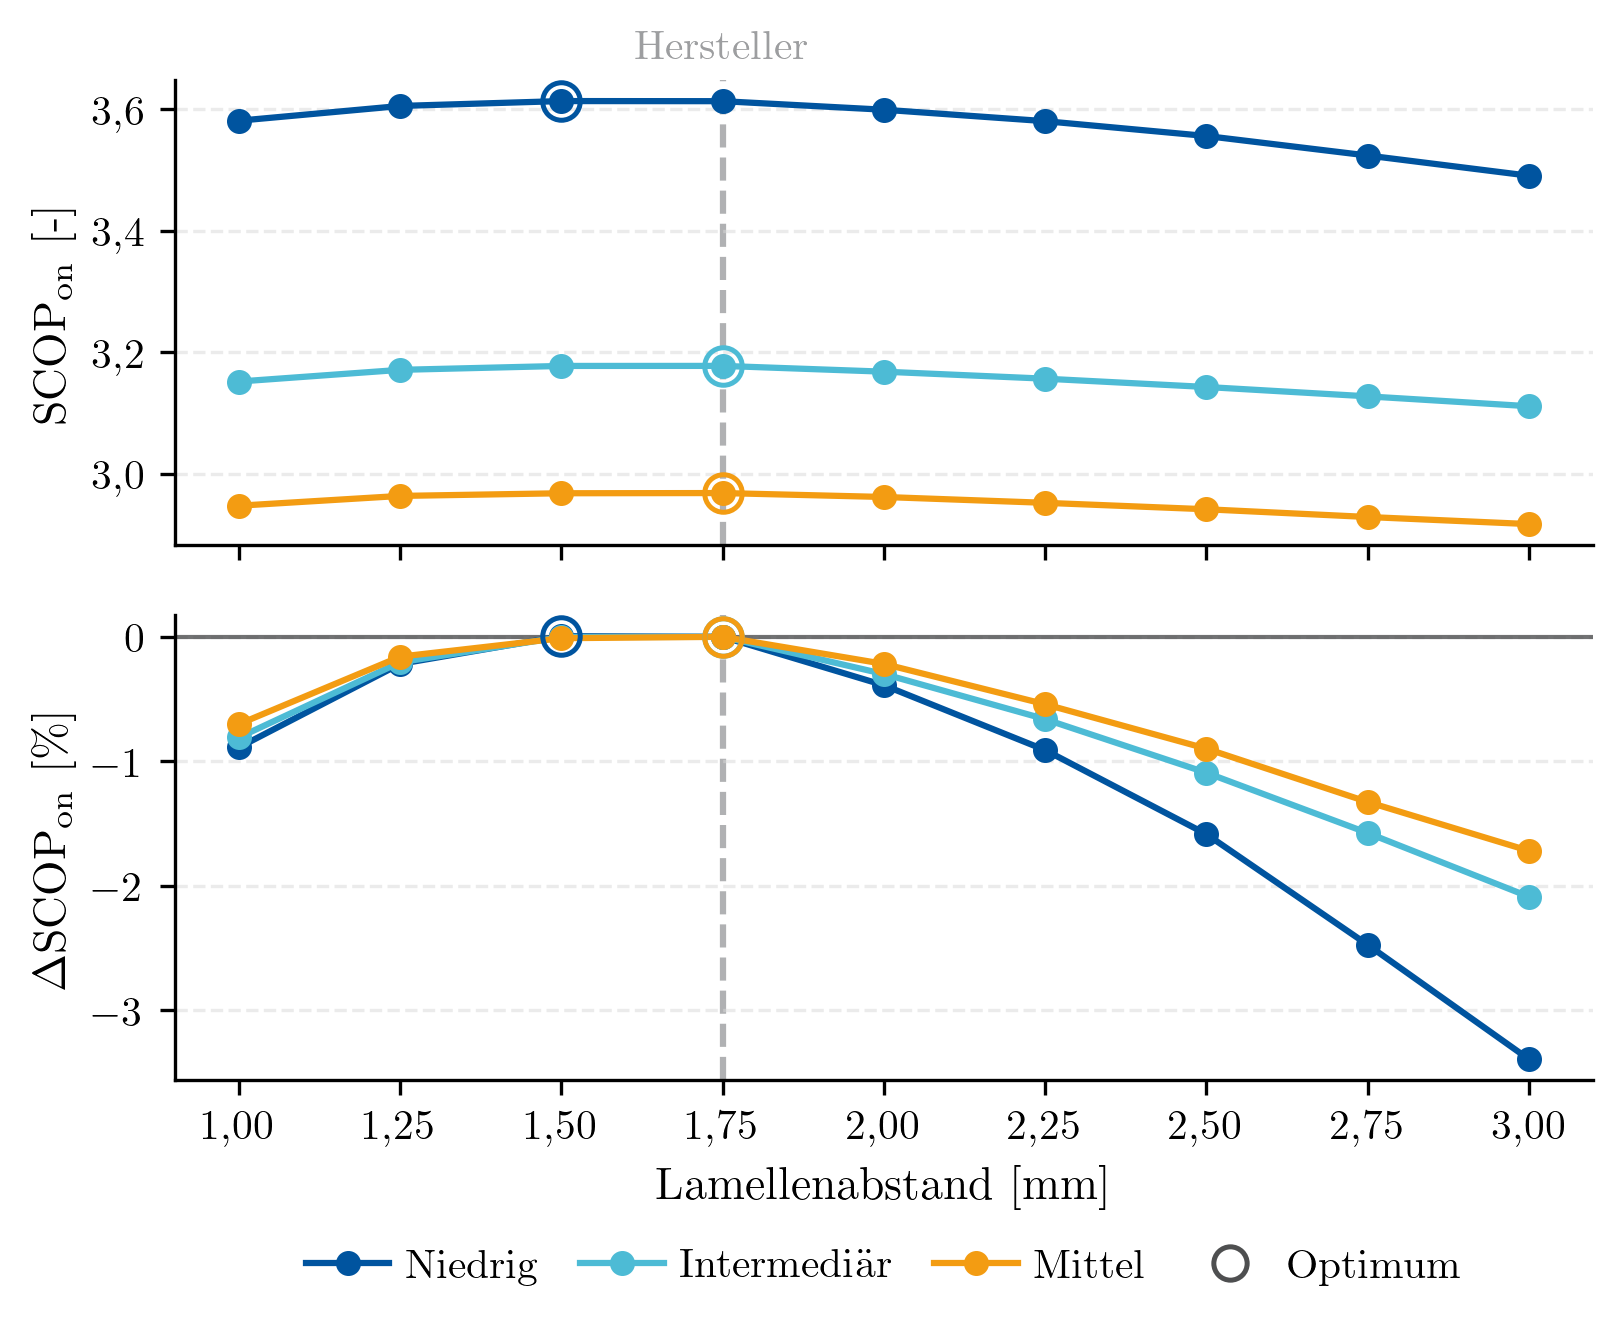

Erfolgreich generiert: 6_scop_optimum_neu_horst.pdf

                    FIN PITCH OPTIMIZATION: SCOP_ON IMPACT                    
| Temp. Level     | Baseline (1.75mm)  | Optimum (Pitch)        | Gain [%]   |
|-----------------|--------------------|------------------------|------------|
| Niedrig         | 3.613              | 3.614 (1.50 mm)        | +0.00532%   |
| Intermediär     | 3.178              | 3.178 (1.75 mm)        | +0.00000%   |
| Mittel          | 2.969              | 2.969 (1.75 mm)        | +0.00000%   |
 * Gain relative to industry standard manufacturer spacing.

[-4.06479337663227, 6.789748834034981, 6.437476208755655, 4.925694011317083, 3.352058297752869, 1.894435419895002, 0.0, -1.7409775952951345]
[-3.896135973136894, 5.229197557323673, 5.045859920411666, 3.9330895899702067, 2.6397781874528015, 1.540243935172536, 0.0, -1.5351501337105167]
[-2.8053277937993615, 3.937620484991866, 4.398179067438557, 3.4272118554940167, 2.28273964767578, 1.188591717593357, 0.0, -1

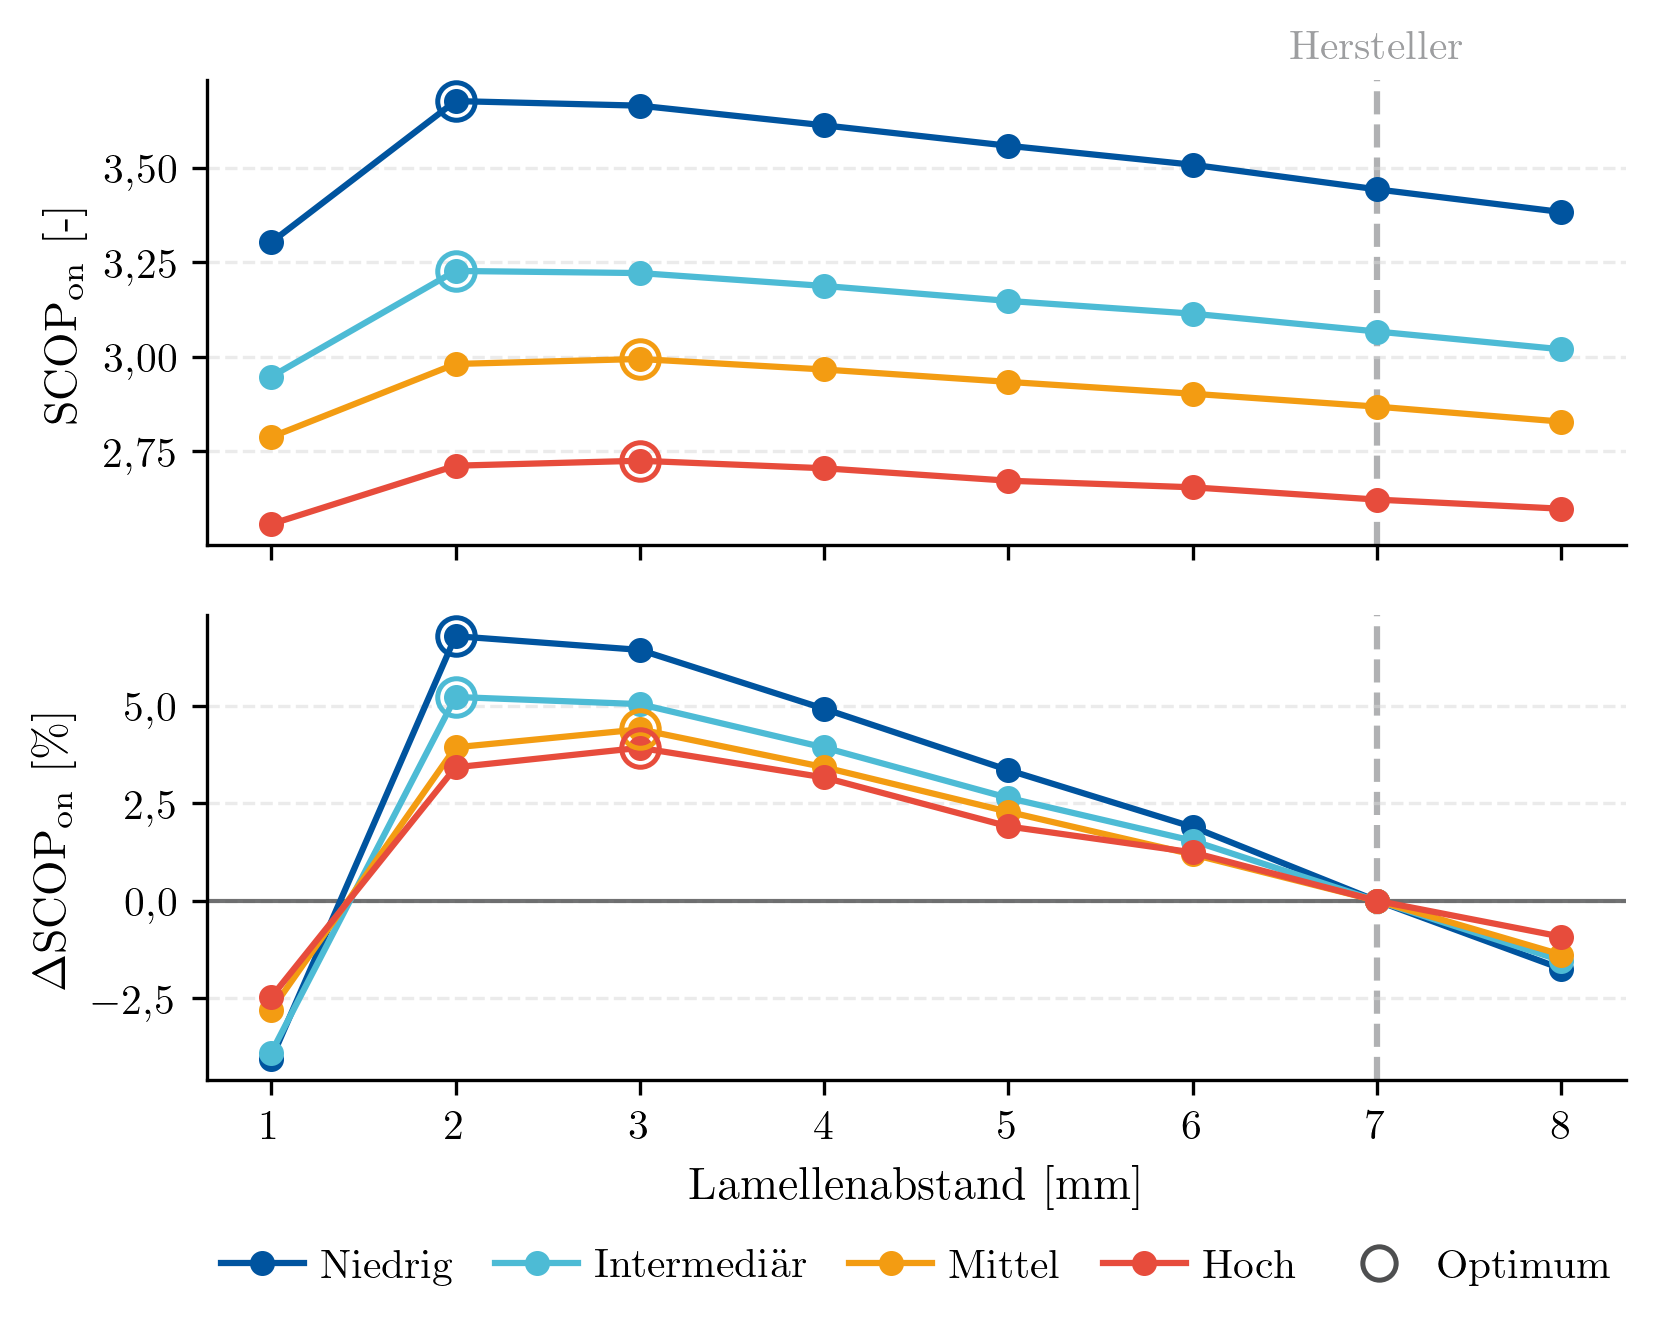

Erfolgreich generiert: 6_scop_optimum_neu_abt.pdf

                    FIN PITCH OPTIMIZATION: SCOP_ON IMPACT                    
| Temp. Level     | Baseline (7.0mm)   | Optimum (Pitch)        | Gain [%]   |
|-----------------|--------------------|------------------------|------------|
| Niedrig         | 3.443              | 3.677 (2.00 mm)        | +6.78975%   |
| Intermediär     | 3.067              | 3.227 (2.00 mm)        | +5.22920%   |
| Mittel          | 2.868              | 2.994 (3.00 mm)        | +4.39818%   |
| Hoch            | 2.622              | 2.725 (3.00 mm)        | +3.92463%   |
 * Gain relative to industry standard manufacturer spacing.

[-5.090526484059044, 3.4972058821425067, 3.9634656477745, 3.3059330111603558, 2.3565905008514187, 1.6705895001628557, 0.0, -1.736863392155874]


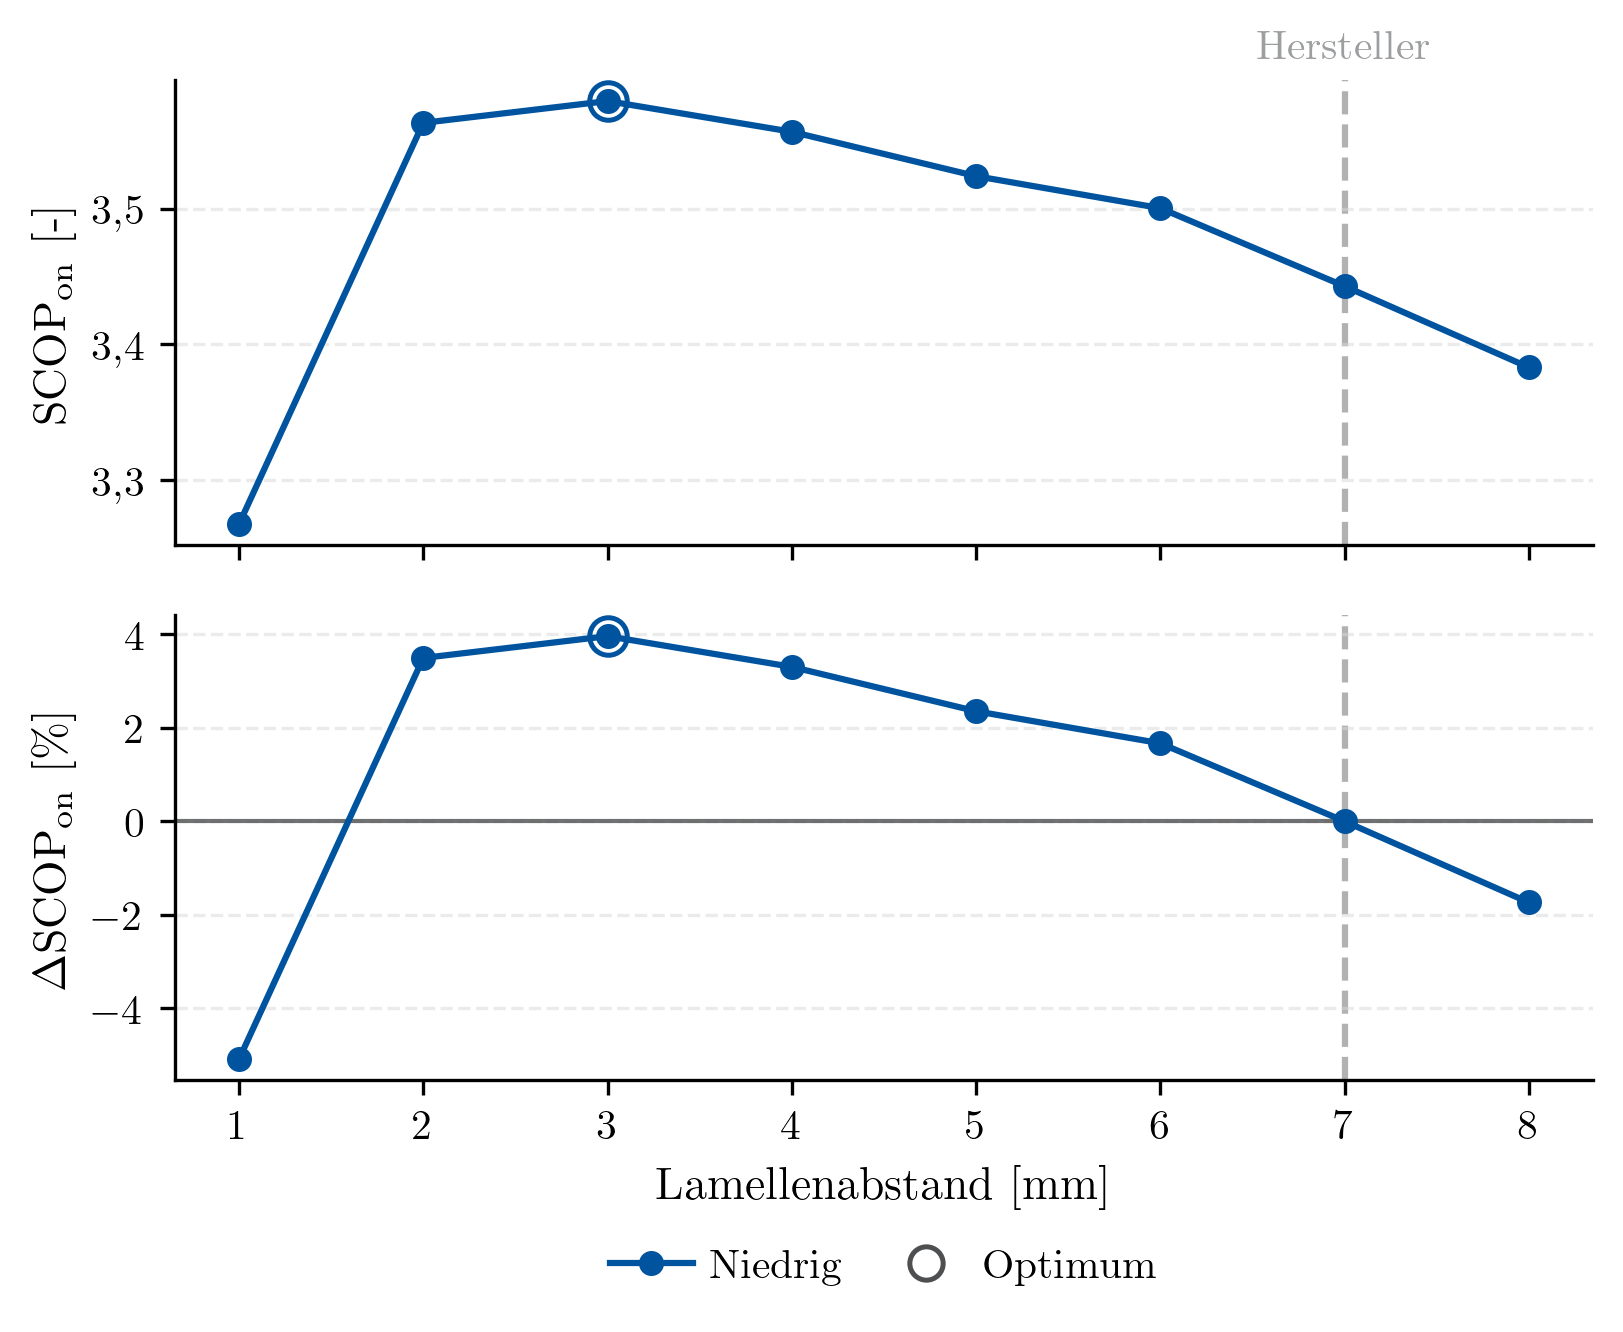

Erfolgreich generiert: delete.pdf

                    FIN PITCH OPTIMIZATION: SCOP_ON IMPACT                    
| Temp. Level     | Baseline (7.0mm)   | Optimum (Pitch)        | Gain [%]   |
|-----------------|--------------------|------------------------|------------|
| Niedrig         | 3.443              | 3.579 (3.00 mm)        | +3.96347%   |
 * Gain relative to industry standard manufacturer spacing.


Alle Plots wurden erstellt.


In [108]:
import os
import pickle
import locale
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# =============================================================================
# LOCALE & GLOBALE PLOT-EINSTELLUNGEN FÜR DIE MASTERARBEIT
# =============================================================================

try:
    locale.setlocale(locale.LC_NUMERIC, "de_DE.UTF-8")
except locale.Error:
    try:
        locale.setlocale(locale.LC_NUMERIC, "de_DE")
    except locale.Error:
        print("Warnung: Deutsches Locale konnte nicht geladen werden. Nutze Fallback.")

def set_plot_style():
    """
    Setzt die globalen Matplotlib-Parameter für einen flacheren Plot 
    und gibt eine thermische Farbpalette zurück.
    """
    cm_to_inch = 1 / 2.54
    width_cm = 15.5
    # Höhe etwas vergrößert, um Platz für 2 Subplots zu schaffen, 
    # behält aber den breiten, eleganten Look bei.
    height_cm = 11.0 

    plt.rcParams.update({
        "figure.figsize": (width_cm * cm_to_inch, height_cm * cm_to_inch),
        "figure.dpi": 300,
        "text.usetex": True,
        "text.latex.preamble": r"\usepackage{icomma} \usepackage{amsmath}",
        "font.family": "serif",
        "font.size": 11,
        "axes.labelsize": 11,
        "legend.fontsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "axes.formatter.use_locale": True,
        "axes.linewidth": 0.8,
        "grid.color": "#D9D9D9",
        "grid.linestyle": "--",
        "grid.alpha": 0.5,
        "legend.frameon": False,
        "savefig.bbox": "tight",
        "savefig.format": "pdf"
    })

    # Thermischer Farbverlauf (Kalt -> Heiß) für intuitive Lesbarkeit
    return {
        "Low": "#00549F",       # Tiefblau (Kalt)
        "Inter": "#4DBBD5",     # Cyan/Hellblau (Kühl)
        "Medium": "#F39C12",    # Orange (Warm)
        "High": "#E74C3C",      # Rot (Heiß)
        "dark_grey": "#4E4F50",
        "mid_grey": "#9D9EA0",
        "light_grey": "#D9D9D9"
    }

def process_and_plot(filename, manufacturer_pitch_mm, output_filename, colors):
    """Liest die Daten für ein spezifisches Setup ein und generiert den Plot."""
    
    try:
        with open(filename, "rb") as f:
            all_data = pickle.load(f)
            scop_results_dict = all_data.get("SCOP_on", {})
    except FileNotFoundError:
        print(f"Error: Datei '{filename}' nicht gefunden. Überspringe...")
        return
    
    if not scop_results_dict:
        print(f"Fehler: Keine SCOP-Daten in '{filename}' gefunden.")
        return

    # Diese Reihenfolge diktiert exakt den Aufbau der Legende
    SELECTED_APPS = ['Low', 'Inter', 'Medium', 'High']
    app_translations = {'Low': 'Niedrig', 'Inter': 'Intermediär', 'Medium': 'Mittel', 'High': 'Hoch'}
    sorted_pitches_m = sorted(scop_results_dict.keys())
    
    # Zwei Subplots untereinander mit gemeinsamer X-Achse
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, gridspec_kw={'hspace': 0.15})
    
    lines_for_legend = []
    labels_for_legend = []

    # Iteration über die Vorlauftemperaturen
    for app in SELECTED_APPS:
        valid_pitches = [p for p in sorted_pitches_m if app in scop_results_dict[p]]
        if not valid_pitches: 
            continue 
            
        x_vals = [p * 1000.0 for p in valid_pitches] # m -> mm
        y_vals = [scop_results_dict[p][app] for p in valid_pitches]
        
        c = colors.get(app, colors["dark_grey"])
        label_de = app_translations.get(app, app)
        
        # --- OBERER PLOT (Absolute Werte) ---
        line = ax1.plot(x_vals, y_vals, color=c, marker='o', markersize=5, 
                        linestyle='-', linewidth=1.5, zorder=4)
        
        # Optimum markieren
        max_scop = max(y_vals)
        idx_max = y_vals.index(max_scop)
        max_pitch = x_vals[idx_max]
        
        ax1.plot(max_pitch, max_scop, marker='o', markersize=9, 
                 markeredgecolor=c, markerfacecolor='none', 
                 markeredgewidth=1.2, linestyle='None', zorder=5)
                 
        # Für die Legende speichern wir nur die Handles vom oberen Plot
        lines_for_legend.append(line[0])
        labels_for_legend.append(label_de)

        # --- UNTERER PLOT (Relative Abweichungen in %) ---
        # Robustes Suchen des Basiswerts beim Hersteller-Abstand (Rundung wg. Float-Ungenauigkeiten)
        results_for_temp = {round(p, 3): y for p, y in zip(x_vals, y_vals)}
        val_baseline = results_for_temp.get(round(manufacturer_pitch_mm, 3), np.nan)
        
        if not np.isnan(val_baseline) and val_baseline > 0:
            # Berechnung der prozentualen Abweichung
            y_rel = [(y / val_baseline - 1) * 100 for y in y_vals]
            max_rel = y_rel[idx_max] # Gleiches Optimum wie oben
            
            # Kurve zeichnen
            ax2.plot(x_vals, y_rel, color=c, marker='o', markersize=5, 
                     linestyle='-', linewidth=1.5, zorder=4)

            print(y_rel)
                     
            # Optimum unten markieren
            ax2.plot(max_pitch, max_rel, marker='o', markersize=9, 
                     markeredgecolor=c, markerfacecolor='none', 
                     markeredgewidth=1.2, linestyle='None', zorder=5)

    # =============================================================================
    # LINIEN & TEXTE (Hersteller & Y=0)
    # =============================================================================
    # Hersteller-Linie in beiden Subplots
    for ax in (ax1, ax2):
        ax.axvline(x=manufacturer_pitch_mm, color=colors["mid_grey"], linestyle='--', 
                   linewidth=1.5, alpha=0.8, zorder=1)

    # Text horizontal über der OBEREN Plot-Fläche platziert
    ax1.text(manufacturer_pitch_mm, 1.03, 'Hersteller', 
             color=colors["mid_grey"], fontsize=10, 
             ha='center', va='bottom', transform=ax1.get_xaxis_transform(), clip_on=False)

    # Nulllinie im unteren Plot einzeichnen
    ax2.axhline(y=0, color=colors["dark_grey"], linestyle='-', linewidth=1.0, alpha=0.8, zorder=2)

    # =============================================================================
    # FORMATIERUNG & LEGENDE
    # =============================================================================
    ax1.set_ylabel(r"$\text{SCOP}_\text{on}$ [-]")
    ax2.set_ylabel(r"$\Delta\text{SCOP}_\text{on}$ [\%]")
    ax2.set_xlabel("Lamellenabstand [mm]")
    
    # Grid und Rahmenlinien für beide Achsen
    for ax in (ax1, ax2):
        ax.grid(True, axis='y', linestyle='--', color=colors["light_grey"], linewidth=0.8, alpha=0.5, zorder=0)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    # Optimum Dummy für Legende ans Ende anhängen
    optimum_handle = mlines.Line2D([], [], color='none', marker='o', markersize=8, 
                                   markeredgecolor=colors["dark_grey"], markeredgewidth=1.2)
    
    lines_for_legend.append(optimum_handle)
    labels_for_legend.append('Optimum')

    # Legende zentriert UNTER dem unteren Plot
    ax2.legend(handles=lines_for_legend, labels=labels_for_legend, 
               loc='upper center', bbox_to_anchor=(0.5, -0.28), 
               ncol=len(labels_for_legend), frameon=False, 
               columnspacing=1.0, handletextpad=0.4)

    # =============================================================================
    # EXPORT
    # =============================================================================
    output_dir = r"J:\Masterarbeit_Nils_Baumeister\02_Schriftliche_Ausarbeitung\Graphiken"
    os.makedirs(output_dir, exist_ok=True)
    output_path = os.path.join(output_dir, output_filename)
    
    plt.savefig(output_path, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    
    print(f"Erfolgreich generiert: {output_filename}")

    # =============================================================================
    # 5. PERFORMANCE COMPARISON TABLE (ASCII)
    # =============================================================================
    print("\n" + "="*78)
    print(f"{'FIN PITCH OPTIMIZATION: SCOP_ON IMPACT':^78}")
    print("="*78)
    print(f"| {'Temp. Level':<15} | {f'Baseline ({manufacturer_pitch_mm}mm)':<18} | {'Optimum (Pitch)':<22} | {'Gain [%]':<10} |")
    print("|" + "-"*17 + "|" + "-"*20 + "|" + "-"*24 + "|" + "-"*12 + "|")

    for app in SELECTED_APPS:
        results_for_temp = {p*1000.0: scop_results_dict[p][app] for p in sorted_pitches_m if app in scop_results_dict[p]}
        
        if not results_for_temp:
            continue

        val_baseline = results_for_temp.get(manufacturer_pitch_mm, np.nan)
        opt_pitch_mm = max(results_for_temp, key=results_for_temp.get)
        val_opt = results_for_temp[opt_pitch_mm]
        
        gain = ((val_opt / val_baseline) - 1) * 100 if not np.isnan(val_baseline) and val_baseline > 0 else 0.0
        
        label_de = app_translations.get(app, app)
        opt_str = f"{val_opt:.3f} ({opt_pitch_mm:>4.2f} mm)"
        
        print(f"| {label_de:<15} | {val_baseline:<18.3f} | {opt_str:<22} | +{gain:>6.5f}%   |")

    print("="*78)
    print(" * Gain relative to industry standard manufacturer spacing.\n")

def main():
    colors = set_plot_style()
    
    # Konfiguration für beide Plots (Namen gemäß Vorgabe angepasst)
    configs = [
        ("simulation_data/final/06_SCOP_horst_final.pkl", 1.75, "6_scop_optimum_neu_horst.pdf"),
        ("simulation_data/final/06_SCOP_abt_final_2.pkl", 7.0, "6_scop_optimum_neu_abt.pdf"),
        ("simulation_data/grand_scop_simulation_results_abt_betta_stuff_SCOP.pkl", 7.0, "delete.pdf"),
    ]
    
    print("Starte Plot-Generierung...\n")
    for filename, m_pitch, out_name in configs:
        process_and_plot(filename, m_pitch, out_name, colors)
    print("\nAlle Plots wurden erstellt.")

if __name__ == "__main__":
    main()

# Abschlussvortrag

## SCOP

Starte Plot-Generierung für PowerPoint...

Verarbeite: simulation_data/final/06_SCOP_abt_final_2.pkl


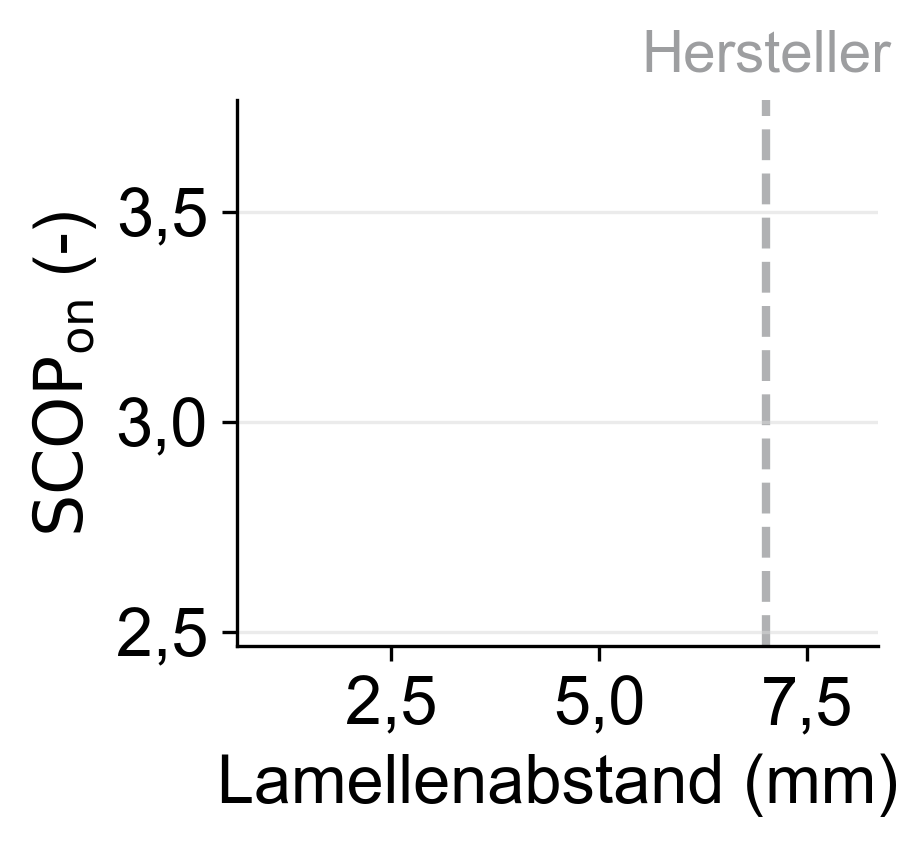

Erfolgreich generiert: PP_temp_blank.svg


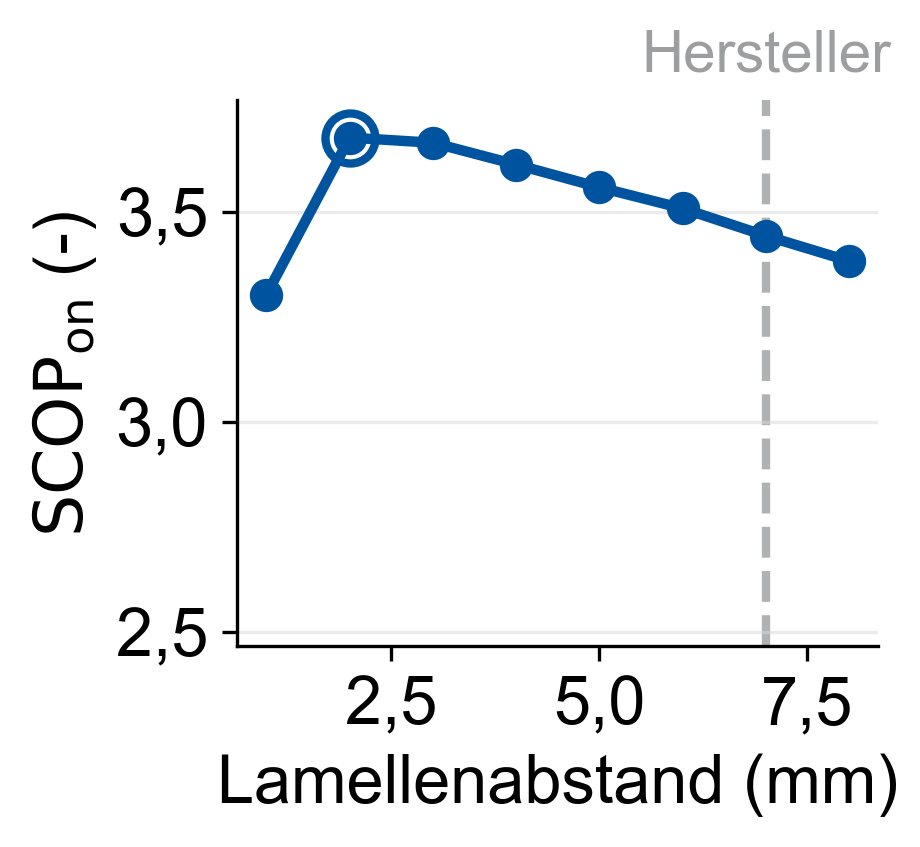

Erfolgreich generiert: PP_temp_intro.svg


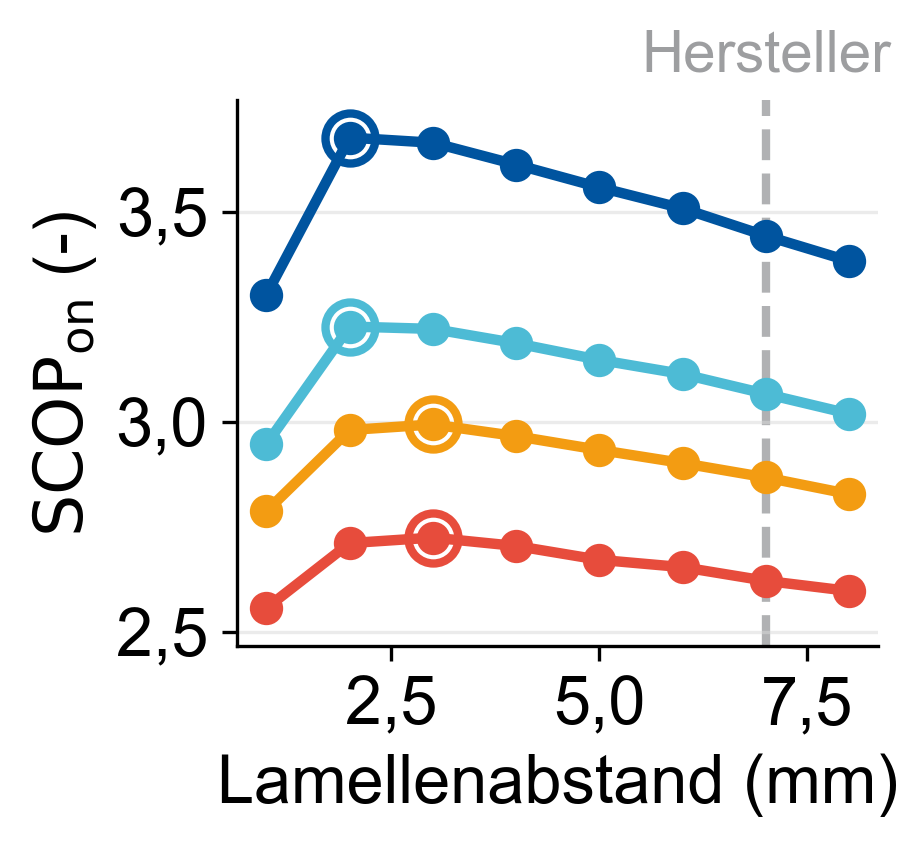

Erfolgreich generiert: PP_temp_full.svg

Alle Plots für die Präsentation wurden erstellt und im SVG-Format gespeichert.


In [ ]:
import os
import pickle
import locale
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# =============================================================================
# LOCALE SETTINGS 
# =============================================================================
try:
    locale.setlocale(locale.LC_NUMERIC, "de_DE.UTF-8")
except locale.Error:
    try:
        locale.setlocale(locale.LC_NUMERIC, "de_DE")
    except locale.Error:
        print("Warnung: Deutsches Locale konnte nicht geladen werden. Nutze Fallback.")

# =============================================================================
# GLOBAL PLOT-SETTINGS FOR POWERPOINT
# =============================================================================
def set_plot_style():
    """
    Sets global Matplotlib parameters for an elegant, readable presentation look
    and returns a thermic color palette.
    """
    cm_to_inch = 1 / 2.54
    height_cm = 12.0 
    width_cm = 27.0 # Wide 16:9 look for presentations

    # PowerPoint specific font settings
    FONT_FAMILY = "Arial"
    FONT_SIZE = 16

    plt.rcParams.update({
        "figure.figsize": (width_cm * cm_to_inch, height_cm * cm_to_inch),
        "figure.dpi": 300,
        "font.family": FONT_FAMILY,
        "font.size": FONT_SIZE,
        "axes.labelsize": FONT_SIZE,
        "legend.fontsize": FONT_SIZE,
        "xtick.labelsize": FONT_SIZE,
        "ytick.labelsize": FONT_SIZE,
        "axes.formatter.use_locale": True,
        "axes.linewidth": 0.8,
        "grid.color": "#D9D9D9",
        "grid.linestyle": "--",
        "grid.alpha": 0.5,
        "legend.frameon": False,
        "savefig.bbox": "tight",
        "savefig.format": "svg"
    })

    return {
        "Low": "#00549F",       # Tiefblau (Kalt)
        "Inter": "#4DBBD5",     # Cyan/Hellblau (Kühl)
        "Medium": "#F39C12",    # Orange (Warm)
        "High": "#E74C3C",      # Rot (Heiß)
        "dark_grey": "#4E4F50",
        "mid_grey": "#9D9EA0",
        "light_grey": "#D9D9D9"
    }


# =============================================================================
# MAIN PLOTTING FUNCTION
# =============================================================================
def create_scop_plot(scop_results_dict, manufacturer_pitch_mm, temps_to_plot, output_dir, output_filename, colors):
    SELECTED_APPS = ['Low', 'Inter', 'Medium', 'High']
    app_translations = {'Low': 'Niedrig', 'Inter': 'Intermediär', 'Medium': 'Mittel', 'High': 'Hoch'}
    sorted_pitches_m = sorted(scop_results_dict.keys())
    
    fig, ax = plt.subplots(1, 1)
    
    # -------------------------------------------------------------------------
    # 1. SCAN ALL DATA FIRST TO LOCK EXACT AXES LIMITS
    # -------------------------------------------------------------------------
    all_x_vals = []
    all_y_vals = []
    for app in SELECTED_APPS:
        valid_pitches = [p for p in sorted_pitches_m if app in scop_results_dict[p]]
        for p in valid_pitches:
            all_x_vals.append(p * 1000.0)
            all_y_vals.append(scop_results_dict[p][app])

    if all_x_vals and all_y_vals:
        # Include manufacturer pitch in X-limits check
        min_x = min(min(all_x_vals), manufacturer_pitch_mm)
        max_x = max(max(all_x_vals), manufacturer_pitch_mm)
        x_range = max_x - min_x if max_x > min_x else 1.0
        y_range = max(all_y_vals) - min(all_y_vals) if max(all_y_vals) > min(all_y_vals) else 1.0
        
        # Lock in the limits explicitly so they never jump
        ax.set_xlim(min_x - x_range * 0.05, max_x + x_range * 0.05)
        ax.set_ylim(min(all_y_vals) - y_range * 0.08, max(all_y_vals) + y_range * 0.08)

    # -------------------------------------------------------------------------
    # 2. PLOT THE REQUESTED LINES
    # -------------------------------------------------------------------------
    for app in temps_to_plot:
        valid_pitches = [p for p in sorted_pitches_m if app in scop_results_dict[p]]
        if not valid_pitches: 
            continue 
            
        x_vals = [p * 1000.0 for p in valid_pitches] # m -> mm
        y_vals = [scop_results_dict[p][app] for p in valid_pitches]
        
        c = colors.get(app, colors["dark_grey"])
        
        # Plot Data Line
        ax.plot(x_vals, y_vals, color=c, marker='o', markersize=7, 
                linestyle='-', linewidth=2.5, zorder=4)
        
        # Plot Optimum Marker
        max_scop = max(y_vals)
        idx_max = y_vals.index(max_scop)
        max_pitch = x_vals[idx_max]
        
        ax.plot(max_pitch, max_scop, marker='o', markersize=12, 
                 markeredgecolor=c, markerfacecolor='none', 
                 markeredgewidth=2.0, linestyle='None', zorder=5)

    # -------------------------------------------------------------------------
    # 3. COMMON ELEMENTS (Guarantees identical appearance)
    # -------------------------------------------------------------------------
    ax.axvline(x=manufacturer_pitch_mm, color=colors["mid_grey"], linestyle='--', 
                linewidth=2.0, alpha=0.8, zorder=1)

    ax.text(manufacturer_pitch_mm, 1.03, 'Hersteller', 
             color=colors["mid_grey"], fontsize=14, 
             ha='center', va='bottom', transform=ax.get_xaxis_transform(), clip_on=False)

    ax.set_ylabel(r"$\text{SCOP}_\text{on}$ (-)")
    ax.set_xlabel("Lamellenabstand (mm)")
    
    ax.grid(True, axis='y', linestyle='-', color=colors["light_grey"], linewidth=0.8, alpha=0.5, zorder=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # -------------------------------------------------------------------------
    # 4. HARDCODED LEGEND (Always identical, regardless of what's plotted)
    # -------------------------------------------------------------------------
    lines_for_legend = []
    labels_for_legend = []

    # A) "Effizienz-Optimum" goes to the very left (first position)
    optimum_handle = mlines.Line2D([], [], color='none', marker='o', markersize=10, 
                                    markeredgecolor=colors["dark_grey"], markeredgewidth=1.8)
    lines_for_legend.append(optimum_handle)
    labels_for_legend.append('Effizienz-Optimum')

    # B) Add all Temperatures (Even if they aren't visible on the plot yet)
    for app in SELECTED_APPS:
        c = colors.get(app, colors["dark_grey"])
        label_de = app_translations.get(app, app)
        line_handle = mlines.Line2D([], [], color=c, marker='o', markersize=7, 
                                     linestyle='-', linewidth=2.5)
        lines_for_legend.append(line_handle)
        labels_for_legend.append(label_de)

    ax.legend(handles=lines_for_legend, labels=labels_for_legend, 
               loc='upper center', bbox_to_anchor=(0.5, -0.18), 
               ncol=len(labels_for_legend), frameon=False, 
               columnspacing=1.5, handletextpad=0.5)

    # -------------------------------------------------------------------------
    # 5. EXPORT
    # -------------------------------------------------------------------------
    os.makedirs(output_dir, exist_ok=True)
    output_path = os.path.join(output_dir, output_filename)
    
    plt.savefig(output_path, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"Erfolgreich generiert: {output_filename}")

# =============================================================================
# MAIN PROCESS
# =============================================================================
def main():
    colors = set_plot_style()
    output_dir = r"J:\Masterarbeit_Nils_Baumeister\02_Schriftliche_Ausarbeitung\Graphiken"
    
    configs = [
        ("simulation_data/final/06_SCOP_horst_final.pkl", 1.75, "PP_scop_optimum_neu_horst"),
        ("simulation_data/final/06_SCOP_abt_final_2.pkl", 7.0, "PP_scop_optimum_neu_abt"),
        ("simulation_data/grand_scop_simulation_results_abt_betta_stuff_SCOP.pkl", 7.0, "PP_betta_const"),
    ]
    
    print("Starte Plot-Generierung für PowerPoint...\n")
    
    for filename, m_pitch, base_out_name in configs:
        try:
            with open(filename, "rb") as f:
                all_data = pickle.load(f)
                scop_results_dict = all_data.get("SCOP_on", {})
        except FileNotFoundError:
            print(f"Error: Datei '{filename}' nicht gefunden. Überspringe...")
            continue
        
        if not scop_results_dict:
            print(f"Fehler: Keine SCOP-Daten in '{filename}' gefunden.")
            continue

        print(f"Verarbeite: {filename}")
        
        # 1. Generate Blank Plot (No data plotted, only axes and manufacturer line)
        blank_filename = f"{base_out_name}_blank.svg"
        create_scop_plot(scop_results_dict, m_pitch, [], output_dir, blank_filename, colors)

        # 2. Generate Intro Plot (Only 'Low' temperature)
        intro_filename = f"{base_out_name}_intro.svg"
        create_scop_plot(scop_results_dict, m_pitch, ['Low'], output_dir, intro_filename, colors)
        
        # 3. Generate Full Plot (All temperatures)
        full_filename = f"{base_out_name}_full.svg"
        all_temps = ['Low', 'Inter', 'Medium', 'High']
        create_scop_plot(scop_results_dict, m_pitch, all_temps, output_dir, full_filename, colors)
        
    print("\nAlle Plots für die Präsentation wurden erstellt und im SVG-Format gespeichert.")

if __name__ == "__main__":
    main()

## OptiAbt Weiterführende Ergebnisse - Laufzeitoptimum

Gespeichert: J:\Masterarbeit_Nils_Baumeister\02_Schriftliche_Ausarbeitung\Graphiken\PP_dauer_optimum_plus_2_1_base.svg
Gespeichert: J:\Masterarbeit_Nils_Baumeister\02_Schriftliche_Ausarbeitung\Graphiken\PP_dauer_optimum_plus_2_2_cop.svg
Gespeichert: J:\Masterarbeit_Nils_Baumeister\02_Schriftliche_Ausarbeitung\Graphiken\PP_dauer_optimum_plus_2_3_dauer.svg
Gespeichert: J:\Masterarbeit_Nils_Baumeister\02_Schriftliche_Ausarbeitung\Graphiken\PP_dauer_optimum_plus_2_4_optimum.svg


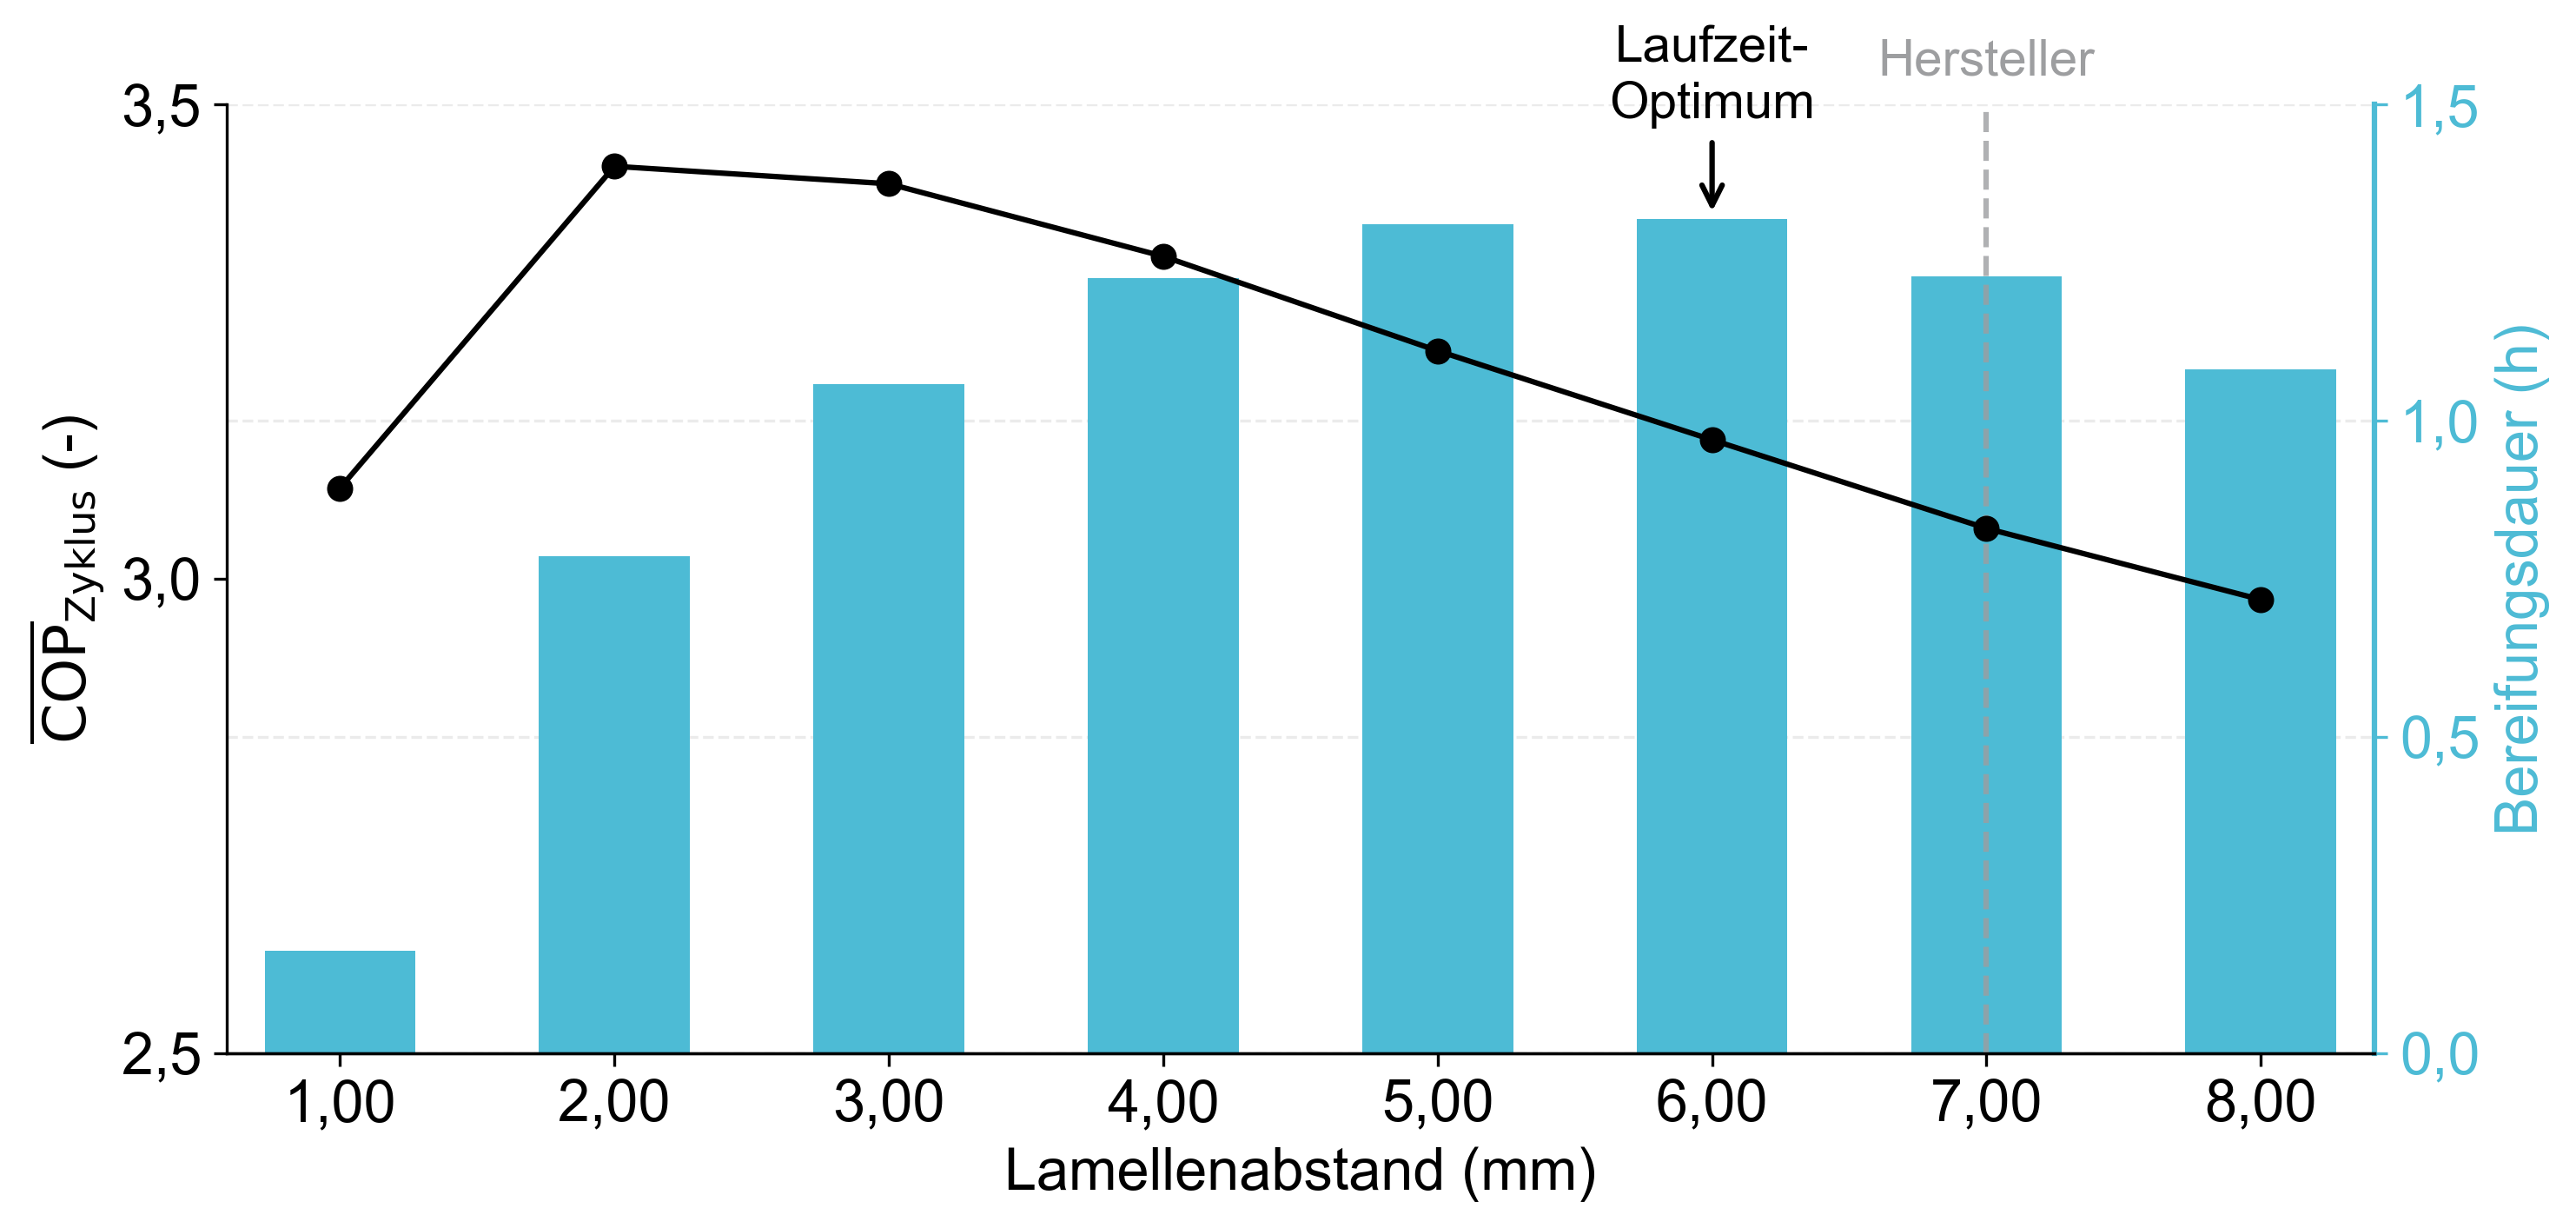

In [15]:
import os
import pickle
import locale
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# =============================================================================
# LOCALE SETTINGS 
# =============================================================================
try:
    locale.setlocale(locale.LC_NUMERIC, "de_DE.UTF-8")
except locale.Error:
    try:
        locale.setlocale(locale.LC_NUMERIC, "de_DE")
    except locale.Error:
        print("Warnung: Deutsches Locale konnte nicht geladen werden. Nutze Fallback.")

# =============================================================================
# GLOBAL PLOT-SETTINGS FOR POWERPOINT
# =============================================================================
def set_plot_style():
    cm_to_inch = 1 / 2.54
    height_cm = 12.0 
    width_cm = 27.0 

    FONT_FAMILY = "Arial"
    FONT_SIZE = 16

    plt.rcParams.update({
        "figure.figsize": (width_cm * cm_to_inch, height_cm * cm_to_inch),
        "figure.dpi": 300,
        "font.family": FONT_FAMILY,
        "font.size": FONT_SIZE,
        "axes.labelsize": FONT_SIZE,
        "legend.fontsize": FONT_SIZE,
        "xtick.labelsize": FONT_SIZE,
        "ytick.labelsize": FONT_SIZE,
        "axes.formatter.use_locale": True,
        "axes.linewidth": 0.8,
        "grid.color": "#D9D9D9",
        "grid.linestyle": "--",
        "grid.alpha": 0.5,
        "legend.frameon": False,
        "savefig.bbox": "tight",
        "savefig.format": "svg"
    })

    return {
        "blue": "#00549F",
        "dark_grey": "#4E4F50",
        "mid_grey": "#9D9EA0",
        "light_grey": "#D9D9D9",
        "abtauen": "#4DBBD5",    
        "luefter": "#F39C12",    
        "verdichter": "#E74C3C"  
    }

def main():
    colors = set_plot_style()
    
    # =============================================================================
    # 1. DATEN LADEN UND EXTRAHIEREN
    # =============================================================================
    filename = "simulation_data/final/abt_low_B_15kW_time.pkl"
    target_app = 'Low'
    target_pt  = 'B'
    ticks_y_cop = np.arange(2.5, 4.0, 0.5) 
    ticks_y_time = np.arange(0, 2, 0.5)

    # filename = "simulation_data/final/abt_low_A_11-5kW_time.pkl"
    # target_app = 'Low'
    # target_pt  = 'A'
    # ticks_y_cop = np.arange(2.5, 4.0, 0.5) 
    # ticks_y_time = np.arange(0, 5, 1)

    MANUFACTURER_PITCH_MM = 7.0

    try:
        with open(filename, "rb") as f:
            all_data = pickle.load(f)
            all_runs_data = all_data["runs_data"]
    except FileNotFoundError:
        print(f"Error: Datei '{filename}' nicht gefunden.")
        return
    
    extracted_data = {}

    for run in all_runs_data:
        if "metadata" not in run or "error" in run:
            continue
            
        meta = run["metadata"]
        context = meta.get("norm_context", {})

        if context.get("application") == target_app and context.get("test_point") == target_pt:
            inputs = meta.get("inputs", {})
            pitch_m = inputs.get("pitch", 0)
            pitch_mm = pitch_m * 1000.0
            
            time_arr = np.array(run.get("time", []), dtype=float)
            dp_air = np.array(run.get("dp_air", []), dtype=float)
            space_m = np.array(run.get("space_between_frost", []), dtype=float)
            
            valid_idx = ~np.isnan(dp_air) & ~np.isnan(space_m)
            time_arr = time_arr[valid_idx]
            dp_air = dp_air[valid_idx]
            space_m = space_m[valid_idx]
            
            if len(dp_air) > 0:
                thickness_mm = (pitch_m - space_m) / 2.0 * 1000.0
                
                extracted_data[pitch_mm] = {
                    "final_time": time_arr[-1],
                    "dp_air_full": dp_air,
                    "final_thickness": thickness_mm[-1],
                    "cop": inputs.get("cycle-COP", 0)
                }

    if not extracted_data:
        print(f"Keine Daten gefunden.")
        return

    sorted_pitches = sorted(extracted_data.keys())
    x_pitches = np.array(sorted_pitches)
    y_time = np.array([extracted_data[p]["final_time"] for p in sorted_pitches]) / 60.0
    y_cop = np.array([extracted_data[p]["cop"] for p in sorted_pitches]) 

    bar_width = np.min(np.diff(sorted_pitches)) * 0.55 if len(sorted_pitches) > 1 else 0.3

    # =============================================================================
    # 2. PLOTTING SETUP & TICKS DEFINIEREN
    # =============================================================================


    fig, ax1 = plt.subplots()
    ax1_twin = ax1.twinx()
    
    color_cop = "black"
    color_dur = colors["abtauen"] 
    color_manuf = colors["mid_grey"]

    # -------------------------------------------------------------------------
    # ALLE ELEMENTE ZEICHNEN (zunächst unsichtbar gemacht, wo nötig)
    # -------------------------------------------------------------------------
    
    # --- BASIS: Achsen, Raster, Ticks ---
    ax1.set_xlabel("Lamellenabstand (mm)")
    ax1.set_ylabel(r"$\overline{\text{COP}}_\text{Zyklus}$ (-)", color=color_cop)
    ax1_twin.set_ylabel("Bereifungsdauer (h)", color=color_dur)
    
    # X-Achse
    pad_x = bar_width * 0.75
    ax1.set_xlim(min(x_pitches) - pad_x, max(x_pitches) + pad_x)
    plt.xticks(x_pitches, [f"{p:.2f}".replace('.', ',') for p in x_pitches])

    # Y-Achsen festsetzen (wichtig für Animation!)
    ax1.set_yticks(ticks_y_cop)
    ax1.set_ylim(min(ticks_y_cop), max(ticks_y_cop))
    ax1.tick_params(axis='y', colors=color_cop)
    
    ax1_twin.set_yticks(ticks_y_time)
    ax1_twin.set_ylim(min(ticks_y_time), max(ticks_y_time))
    ax1_twin.tick_params(axis='y', colors=color_dur)

    # Styling
    ax1_twin.spines['right'].set_color(color_dur)
    ax1_twin.spines['right'].set_linewidth(1.5)
    ax1_twin.grid(axis='y', linestyle='--', linewidth=0.8, alpha=0.5, zorder=0)
    ax1_twin.set_axisbelow(True)
    ax1.grid(False) 

    # Spines aufräumen
    ax1.spines['top'].set_visible(False)
    ax1_twin.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1_twin.spines['left'].set_visible(False)

    # --- ELEMENT 1: Herstellerlinie (ganz im Hintergrund) ---
    line_manuf = ax1.axvline(x=MANUFACTURER_PITCH_MM, color=color_manuf, linestyle='--', linewidth=1.5, alpha=0.8, zorder=0)
    text_manuf = ax1.text(MANUFACTURER_PITCH_MM, 1.02, 'Hersteller', color=color_manuf, fontsize=14, 
                          ha='center', va='bottom', transform=ax1.get_xaxis_transform(), clip_on=False, zorder=0)

    # --- ELEMENT 2: COP Daten ---
    line_cop, = ax1.plot(x_pitches, y_cop, color=color_cop, linestyle='-', linewidth=1.5, 
                         marker='o', markersize=6, markerfacecolor=color_cop, markeredgewidth=1.2, zorder=10)
    line_cop.set_visible(False)

    # --- ELEMENT 3: Bereifungsdauer ---
    bars_time = ax1_twin.bar(x_pitches, y_time, width=bar_width, color=color_dur, alpha=1.0, zorder=2)
    for bar in bars_time:
        bar.set_visible(False)

    # --- ELEMENT 4: Optimum ---
    max_idx = np.argmax(y_time)
    optimum_text = ax1_twin.annotate('Laufzeit-\nOptimum', 
                                     xy=(x_pitches[max_idx], y_time[max_idx]), 
                                     xytext=(0, 25), textcoords='offset points', 
                                     ha='center', va='bottom', color="black",
                                     fontsize=14, zorder=15,
                                     arrowprops=dict(arrowstyle="->", color="black", lw=1.5))
    optimum_text.set_visible(False)
    
    # Layering korrigieren
    ax1.set_zorder(ax1_twin.get_zorder() + 1)
    ax1.patch.set_visible(False)

    # =============================================================================
    # 3. EXPORT DER 4 STADIEN
    # =============================================================================
    output_dir = r"J:\Masterarbeit_Nils_Baumeister\02_Schriftliche_Ausarbeitung\Graphiken"
    os.makedirs(output_dir, exist_ok=True)
    base_name = "PP_dauer_optimum_plus_2"
    # base_name = "PP_dauer_optimum_minus_7"


    # STUFE 1: Nur Achsen und Hersteller
    path_1 = os.path.join(output_dir, f"{base_name}_1_base.svg")
    plt.savefig(path_1)
    print(f"Gespeichert: {path_1}")

    # STUFE 2: + COP
    line_cop.set_visible(True)
    path_2 = os.path.join(output_dir, f"{base_name}_2_cop.svg")
    plt.savefig(path_2)
    print(f"Gespeichert: {path_2}")

    # STUFE 3: + Dauer
    for bar in bars_time:
        bar.set_visible(True)
    path_3 = os.path.join(output_dir, f"{base_name}_3_dauer.svg")
    plt.savefig(path_3)
    print(f"Gespeichert: {path_3}")

    # STUFE 4: + Optimum
    optimum_text.set_visible(True)
    path_4 = os.path.join(output_dir, f"{base_name}_4_optimum.svg")
    plt.savefig(path_4)
    print(f"Gespeichert: {path_4}")

    # Zum Schluss noch einmal alles anzeigen (optional, falls du es beim Ausführen sehen willst)
    plt.show()
    plt.close()

if __name__ == "__main__":
    main()

## Eine WP Simulation

In [16]:
import os
import pickle
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec
import math

# =============================================================================
# 1. GLOBALE FORMATIERUNGS-EINSTELLUNGEN
# =============================================================================
def set_plot_style():
    cm_to_inch = 1 / 2.54
    height_cm = 13.0 
    width_cm = 35.0 

    FONT_FAMILY = "Arial"
    FONT_SIZE = 16

    plt.rcParams.update({
        "figure.figsize": (width_cm * cm_to_inch, height_cm * cm_to_inch),
        "figure.dpi": 1000,
        "text.usetex": False,
        "font.family": "Arial",
        "font.size": FONT_SIZE,
        "axes.labelsize": FONT_SIZE,
        "legend.fontsize": FONT_SIZE,
        "xtick.labelsize": FONT_SIZE,
        "ytick.labelsize": FONT_SIZE,
        "axes.formatter.use_locale": True,
        "axes.linewidth": 0.8,
        "grid.color": "#D9D9D9",
        "grid.linestyle": "--",
        "grid.alpha": 0.5,
        "legend.frameon": False,
        "savefig.bbox": "tight",
        "savefig.format": "svg"
    })

    return {
        "blue": "#00549F",
        "red": "#DD402D",
        "green": "#70AD47",
        "black": "black",
        "mid_grey": "#9D9EA0",
        "light_grey": "#D9D9D9"
    }

COLORS = set_plot_style()

OUTPUT_DIR = r"J:\Masterarbeit_Nils_Baumeister\02_Schriftliche_Ausarbeitung\Graphiken"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# =============================================================================
# 2. HELPER: DEUTSCHES ZAHLENFORMAT (Kommata statt Punkte)
# =============================================================================
def german_formatter(x, pos):
    return f"{x:g}".replace(".", ",")

# =============================================================================
# 3. THESIS PLOTTING LOGIC
# =============================================================================
def plot_thesis_dashboard(results, med_prop, y_config=None):
    """
    y_config format example:
    {
        "frost": {"lims": [0, 1.5], "ticks": [0, 0.5, 1.0, 1.5]},
        "air": {"lims": [0.1, 0.4]},
        ...
    }
    """
    if y_config is None:
        y_config = {}

    t = np.array(results["time"]) / 60.0                
    frost_mass = results["m_frost"]
    air_flow = np.array(results["v_dot_air"]) / 3600    
    comp_speed = np.array(results["speed"]) * 100       
    q_cond = np.array(results["Q_cond"]) / 1000.0       
    q_evap = np.array(results["Q_evap"]) / 1000.0       
    p_el = np.array(results["compressor_power"]) / 1000.0 
    cop = results["COP_wo_defrost"]

    fig = plt.figure()
    gs = gridspec.GridSpec(2, 3, wspace=0.4, hspace=0.95)

    ax_frost = fig.add_subplot(gs[0, 0])
    ax_air   = fig.add_subplot(gs[0, 1])
    ax_speed = fig.add_subplot(gs[0, 2])
    ax_pwr   = fig.add_subplot(gs[1, 0])
    ax_cop   = fig.add_subplot(gs[1, 1])
    ax_ph    = fig.add_subplot(gs[1, 2])
    
    all_axes = [ax_frost, ax_air, ax_speed, ax_pwr, ax_cop, ax_ph]
    time_axes = [ax_frost, ax_air, ax_speed, ax_pwr, ax_cop]

    # --- ZEILE 1: Reifmasse, Luftvolumen, Verdichterdrehzahl ---
    ax_frost.plot(t, frost_mass, color=COLORS["black"], linewidth=1.5, zorder=3)
    ax_frost.set_title('Reifmasse (kg)')
    ax_frost.set_xlabel('Zeit (h)')

    ax_air.plot(t, air_flow, color=COLORS["black"], linewidth=1.5, zorder=3)
    ax_air.set_title(r'Luftvolumenstrom (m$^3$/s)')
    ax_air.set_xlabel('Zeit (h)')

    ax_speed.plot(t, comp_speed, color=COLORS["black"], linewidth=1.5, zorder=3)
    ax_speed.set_title(r'Verdichterdrehzahl (%)')
    ax_speed.set_xlabel('Zeit (h)')

    # --- ZEILE 2: Leistungen, COP, log(p)-h ---
    ax_pwr.plot(t, q_cond, color=COLORS["red"], linewidth=1.5, label=r'$\dot{Q}_\text{Kond}$', zorder=3)
    ax_pwr.plot(t, q_evap, color=COLORS["blue"], linewidth=1.5, label=r'$\dot{Q}_\text{Verd}$', zorder=3)
    ax_pwr.plot(t, p_el, color=COLORS["green"], linewidth=1.5, label=r'$P_\text{el}$', zorder=3)
    ax_pwr.set_title('Leistungen (kW)')
    ax_pwr.set_xlabel('Zeit (h)')
    ax_pwr.legend(loc='upper center', bbox_to_anchor=(0.5, -0.4), frameon=False, ncol=3, columnspacing=0.5, handletextpad=0.4, handlelength=0.8)

    ax_cop.plot(t, cop, color=COLORS["black"], linewidth=1.5, zorder=3)
    ax_cop.set_title('COP (-)')
    ax_cop.set_xlabel('Zeit (h)')

    # log(p)-h Diagramm
    if med_prop is not None:
        try:
            p_crit = med_prop.get_critical_point()[1] if hasattr(med_prop, 'get_critical_point') else 4900000.0 
            p_dome_range = np.logspace(np.log10(1e5), np.log10(p_crit * 0.99), 100)
            h_liq_dome, h_vap_dome, p_dome_success = [], [], []

            for p in p_dome_range:
                try:
                    hl = med_prop.calc_state("PQ", p, 0.0).h / 1000.0
                    hv = med_prop.calc_state("PQ", p, 1.0).h / 1000.0
                    h_liq_dome.append(hl)
                    h_vap_dome.append(hv)
                    p_dome_success.append(p)
                except: pass

            h_dome_full = np.concatenate([h_liq_dome, h_vap_dome[::-1]])
            p_dome_full = np.concatenate([p_dome_success, p_dome_success[::-1]])
            ax_ph.plot(h_dome_full, p_dome_full / 1e5, color=COLORS["mid_grey"], linewidth=1.2, zorder=2)
        except Exception as e:
            print(f"Could not plot saturation dome: {e}")

    cycles = results.get("cycles", [])
    if cycles:
        cycle_start, cycle_end = cycles[0], cycles[-1]
        ax_ph.plot(np.array(cycle_start["h"])/1000.0, np.array(cycle_start["p"])/1e5, color=COLORS["blue"], marker='.', markersize=6, linewidth=1.5, label='Start', zorder=3)
        ax_ph.plot(np.array(cycle_end["h"])/1000.0, np.array(cycle_end["p"])/1e5, color=COLORS["red"], marker='.', markersize=6, linewidth=1.5, label='Ende', zorder=3)
        
    ax_ph.set_yscale('log')
    ax_ph.set_title(r'$\log(p)$-$h$ (bar)')
    ax_ph.set_xlabel('Enthalpie (kJ/kg)')
    ax_ph.legend(loc='upper center', bbox_to_anchor=(0.5, -0.4), ncol=2, frameon=False, columnspacing=0.5, handletextpad=0.4, handlelength=0.8)

    # --- NEW: APPLY CUSTOM Y-LIMITS AND TICKS ---
    axes_map = {
        "frost": ax_frost,
        "air": ax_air,
        "speed": ax_speed,
        "pwr": ax_pwr,
        "cop": ax_cop,
        "ph": ax_ph
    }

    for key, ax in axes_map.items():
        if key in y_config:
            if "lims" in y_config[key]:
                ax.set_ylim(y_config[key]["lims"])
            if "ticks" in y_config[key]:
                ax.set_yticks(y_config[key]["ticks"])

    # Fallback default for ph plot if no custom config provided
    if "ph" not in y_config:
        ax_ph.set_ylim(4, 30)
        ax_ph.set_yticks([5, 10, 30])
    ax_ph.set_yticks([], minor=True)

    # Kosmetik & Layout
    for ax in time_axes:
        ax.set_xlim(0, None) 
        ax.set_xticks([0, 1, 2, 3])

    for ax in all_axes:
        ax.grid(axis='y', zorder=0)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(german_formatter))
        ax.yaxis.set_major_formatter(ticker.FuncFormatter(german_formatter))

    output_path = os.path.join(OUTPUT_DIR, "PP_Waermepumpen_Simulation.svg")
    plt.savefig(output_path, format=plt.rcParams['savefig.format'], bbox_inches='tight')
    plt.show()

# =============================================================================
# 4. DATA LOADING & EXECUTION
# =============================================================================
from vclibpy.media import RefProp

REFPROP_DIR = Path(r"C:\Program Files (x86)\REFPROP")
REFPROP_DLL = REFPROP_DIR / "REFPRP64.DLL"
os.environ["RPPREFIX"] = str(REFPROP_DIR)

med_prop = RefProp(
    fluid_name="R134a",
    dll_path=str(REFPROP_DLL), 
    ref_prop_path=str(REFPROP_DIR),
    copy_dll=False
)

file_path = "simulation_data/final/06_grid_horst_final.pkl"

TARGET_APP = 'Medium'
TARGET_PT = 'A'
TARGET_PITCH_M = 1.75 / 1000.0 

if os.path.exists(file_path):
    with open(file_path, "rb") as f:
        all_data = pickle.load(f)
        all_runs_data = all_data["runs_data"]

    target_result = None
    
    for run in all_runs_data:
        if "metadata" not in run or "error" in run: continue
        meta = run["metadata"]
        if meta.get("norm_context", {}).get("application") == TARGET_APP and \
           meta.get("norm_context", {}).get("test_point") == TARGET_PT and \
           math.isclose(meta.get("inputs", {}).get("pitch", 0), TARGET_PITCH_M, abs_tol=1e-5):
            target_result = run
            break

    if target_result is not None:
        print(f"Datensatz erfolgreich gefunden: {TARGET_APP}, {TARGET_PT} bei {TARGET_PITCH_M*1000} mm.")
        
        # --- DEFINE YOUR Y-LIMITS AND TICKS HERE ---
        # Leave a key out (or leave 'lims'/'ticks' out) to use matplotlib's defaults
        custom_y_config = {
            "frost": {"ticks": [0.0, 0.5, 1.0, 1.5], "lims": [0, 1.5]},
            "air": {"ticks": [0.0, 0.6, 1.2], "lims": [0, 1.3]},
            "speed": {"ticks": [60, 70, 80], "lims": [55, 85]},
            "pwr": {"ticks": [3, 6, 9], "lims": [2.8, 9.2]},
            "cop": {"ticks": [2.0, 2.5], "lims": [1.8, 2.7]},
            "ph": {"ticks": [4, 10, 40], "lims": [2, 41]}
        }
        
        plot_thesis_dashboard(target_result, med_prop, y_config=custom_y_config)
    else:
        print(f"FEHLER: Kein Datensatz für App={TARGET_APP}, Point={TARGET_PT} und Pitch={TARGET_PITCH_M*1000}mm gefunden!")
else:
    print(f"Datei nicht gefunden: {file_path}")

Datensatz erfolgreich gefunden: Medium, A bei 1.75 mm.


## Effizienz Trade Off

Gespeichert: J:\Masterarbeit_Nils_Baumeister\02_Schriftliche_Ausarbeitung\Graphiken\PP_cop_tradeoff_ohne_volumenstrom.svg
Gespeichert: J:\Masterarbeit_Nils_Baumeister\02_Schriftliche_Ausarbeitung\Graphiken\PP_cop_tradeoff_original.svg


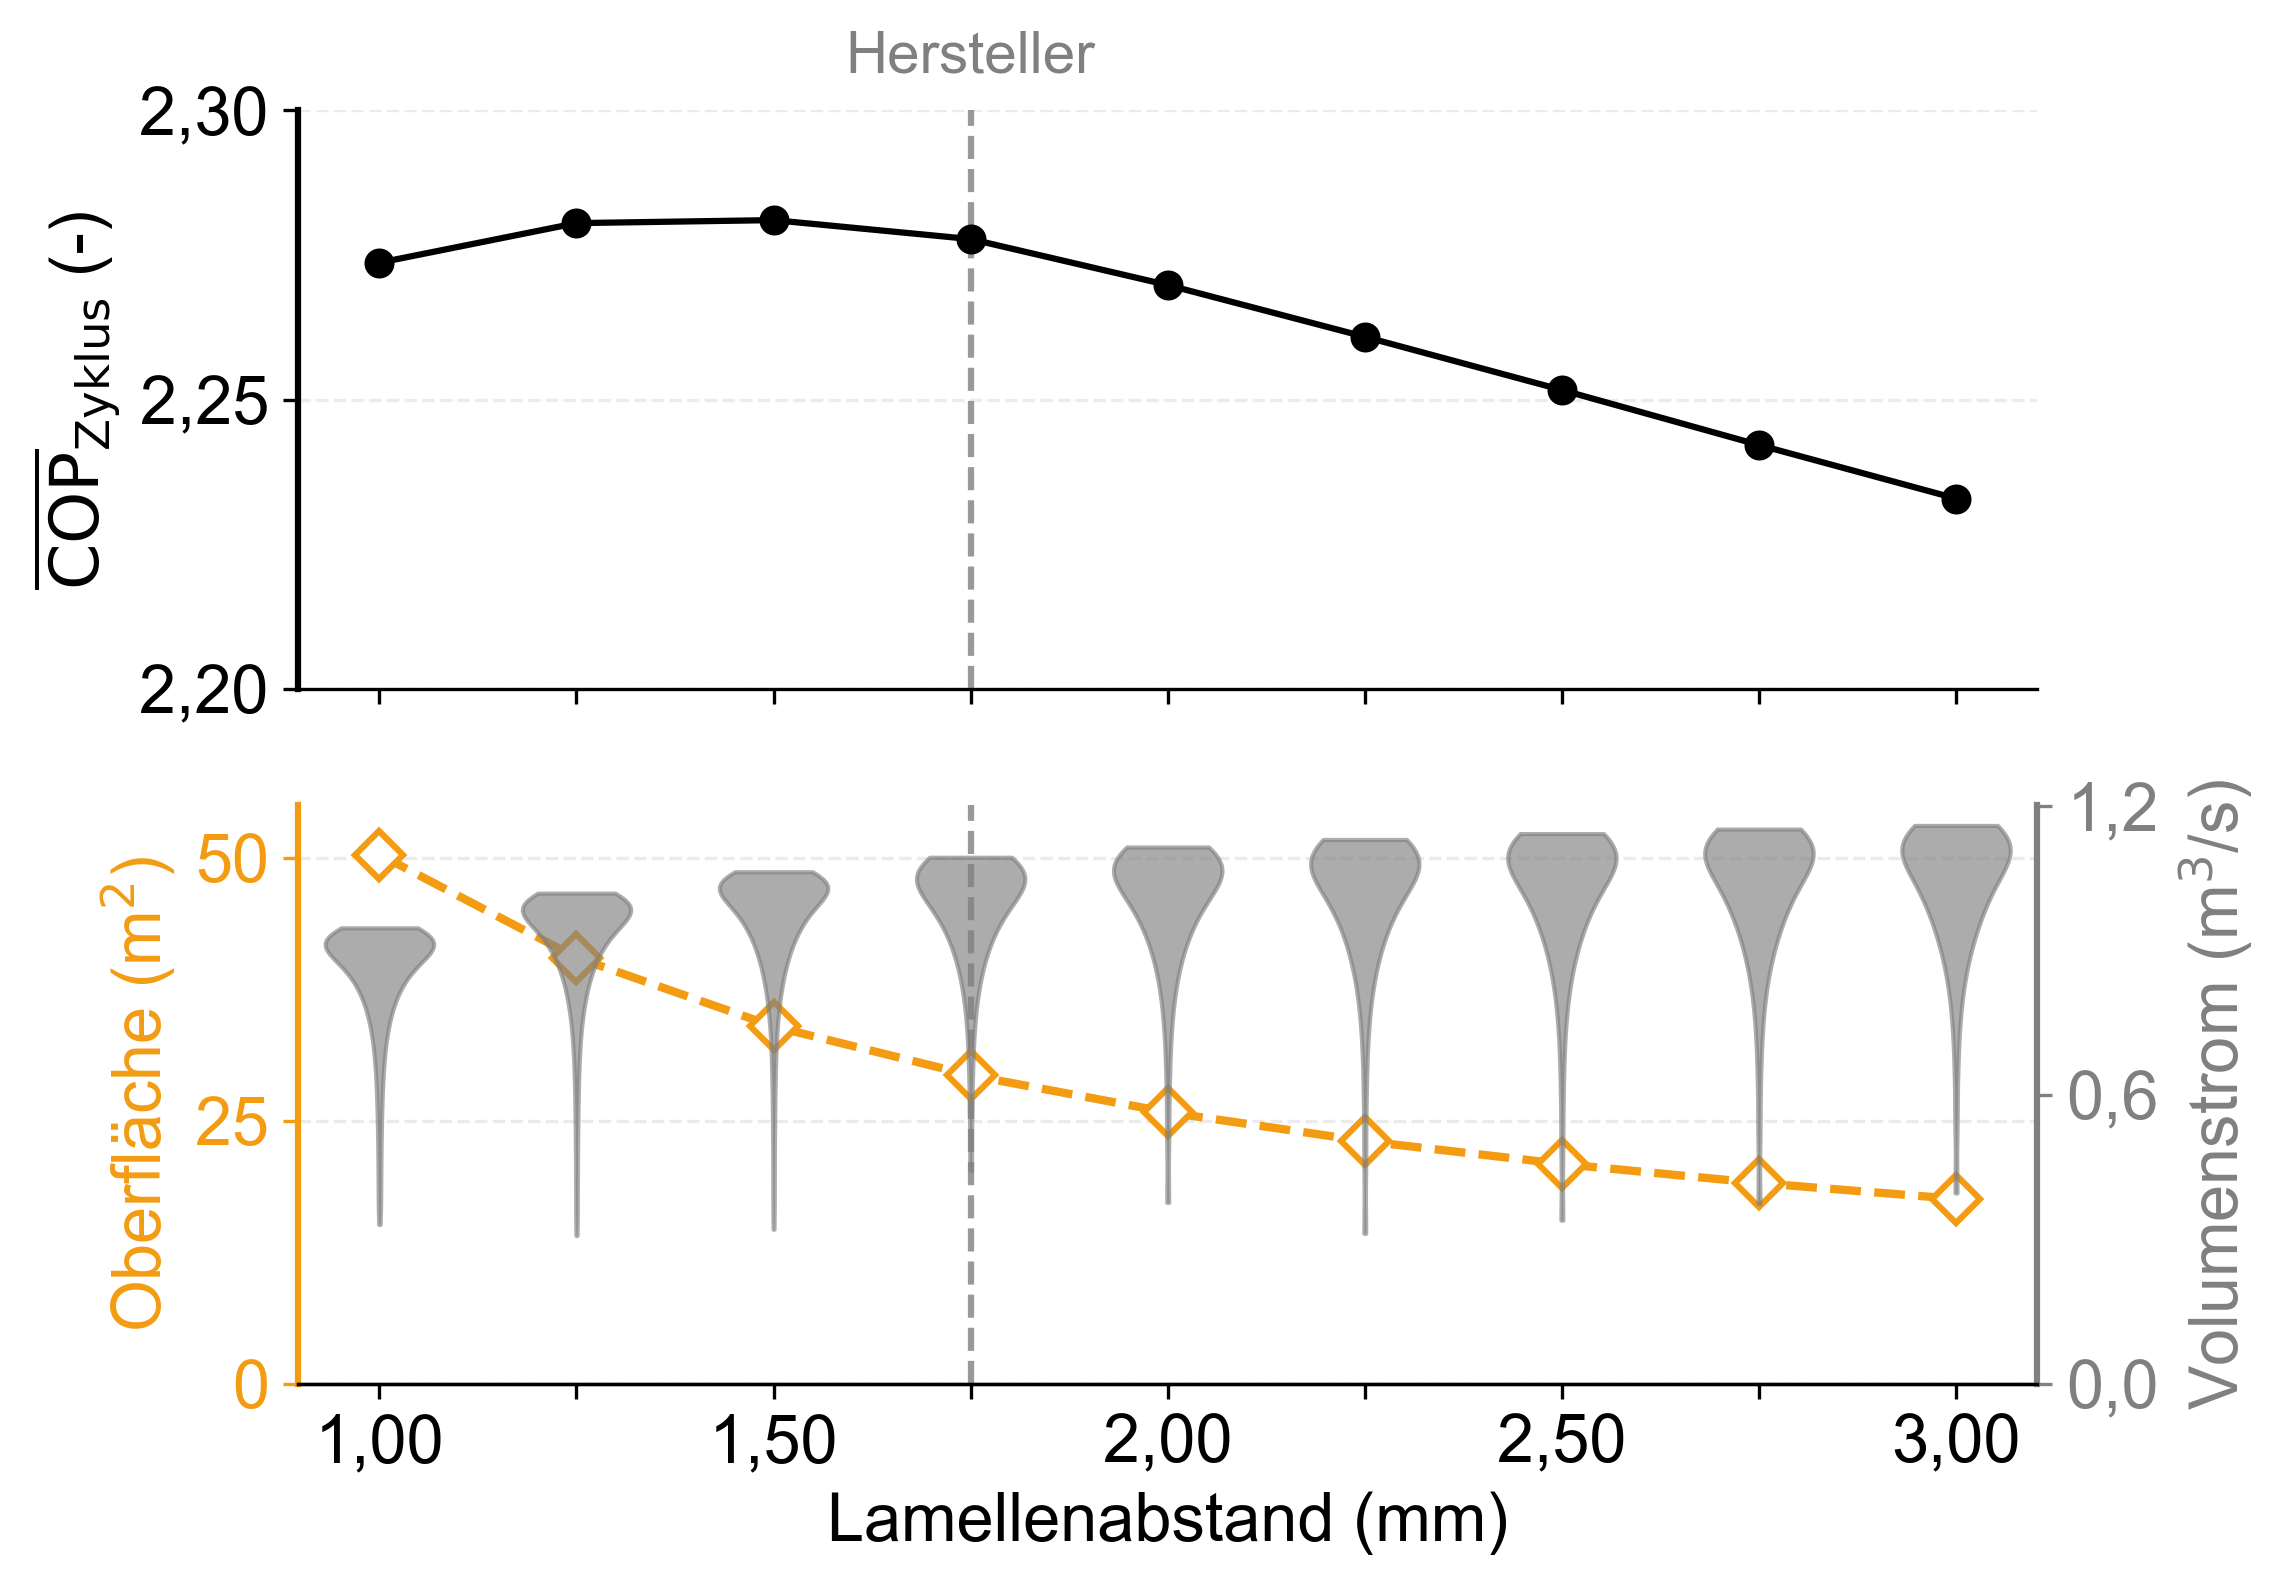

In [24]:
import os
import pickle
import locale
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# =============================================================================
# LOCALE SETTINGS 
# =============================================================================
try:
    locale.setlocale(locale.LC_NUMERIC, "de_DE.UTF-8")
except locale.Error:
    try:
        locale.setlocale(locale.LC_NUMERIC, "de_DE")
    except locale.Error:
        print("Warnung: Deutsches Locale konnte nicht geladen werden. Nutze Fallback.")

# =============================================================================
# GLOBAL PLOT-SETTINGS FOR POWERPOINT
# =============================================================================
def set_plot_style():
    cm_to_inch = 1 / 2.54
    height_cm = 14.0 
    width_cm = 19.0  

    FONT_FAMILY = "Arial"
    FONT_SIZE = 16

    plt.rcParams.update({
        "figure.figsize": (width_cm * cm_to_inch, height_cm * cm_to_inch),
        "figure.dpi": 300,
        "font.family": FONT_FAMILY,
        "font.size": FONT_SIZE,
        "axes.labelsize": FONT_SIZE,
        "legend.fontsize": FONT_SIZE,
        "xtick.labelsize": FONT_SIZE,
        "ytick.labelsize": FONT_SIZE,
        "axes.formatter.use_locale": True,
        "axes.linewidth": 0.8,
        "grid.color": "#D9D9D9",
        "grid.linestyle": "--",
        "grid.alpha": 0.5,
        "legend.frameon": False,
        "savefig.bbox": "tight",
        "savefig.format": "svg"
    })

    return {
        "blue": "#00549F",
        "dark_grey": "#4E4F50",
        "mid_grey": "grey",
        "light_grey": "#D9D9D9",
        "abtauen": "#4DBBD5",    
        "luefter": "#F39C12",    
        "verdichter": "#E74C3C",
        "soft_blue": "#264653",   
        "soft_orange": "#EF233C"  
    }

def main():
    colors = set_plot_style()
    
    # =============================================================================
    # 1. DATEN LADEN UND EXTRAHIEREN
    # =============================================================================
    filename = "simulation_data/final/06_grid_horst_final.pkl"
    target_app = 'Medium'
    target_pt  = 'A'

    MANUFACTURER_PITCH_MM = 1.75
    ticks_y_cop = np.arange(2.2, 2.35, 0.05) 

    try:
        with open(filename, "rb") as f:
            all_data = pickle.load(f)
            all_runs_data = all_data["runs_data"]
    except FileNotFoundError:
        print(f"Error: Datei '{filename}' nicht gefunden.")
        return
    
    extracted_data = {}

    for run in all_runs_data:
        if "metadata" not in run or "error" in run:
            continue
            
        meta = run["metadata"]
        context = meta.get("norm_context", {})

        if context.get("application") == target_app and context.get("test_point") == target_pt:
            inputs = meta.get("inputs", {})
            pitch_m = inputs.get("pitch", 0)
            pitch_mm = pitch_m * 1000.0
            
            # Datenextraktion für Volumenstrom
            v_dot = np.array(run.get("v_dot_air", []), dtype=float)
            v_dot = v_dot[~np.isnan(v_dot)] / 3600.0  
            if len(v_dot) > 1000:
                v_dot = v_dot[::10]
            
            # Datenextraktion für Wärmeübertragende Fläche
            area = np.array(run.get("total_frost_area", []), dtype=float)
            area = area[~np.isnan(area)]
            
            if len(v_dot) > 0 and len(area) > 0:
                extracted_data[pitch_mm] = {
                    "v_dot": v_dot,
                    "area_mean": np.mean(area),
                    "cop": inputs.get("cycle-COP", 0)
                }

    if not extracted_data:
        print(f"Keine Daten gefunden.")
        return

    sorted_pitches = sorted(extracted_data.keys())
    x_pitches = np.array(sorted_pitches)
    y_cop = np.array([extracted_data[p]["cop"] for p in sorted_pitches]) 
    
    # Neue Arrays für Panel 2
    violin_v_data = [extracted_data[p]["v_dot"] for p in sorted_pitches]
    y_area = np.array([extracted_data[p]["area_mean"] for p in sorted_pitches])

    bar_width = np.min(np.diff(sorted_pitches)) * 0.55 if len(sorted_pitches) > 1 else 0.3

    # =============================================================================
    # 2. PLOTTING SETUP (2-Panel Layout)
    # =============================================================================
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, gridspec_kw={'hspace': 0.2})
    ax2_twin = ax2.twinx()
    
    color_manuf = colors["mid_grey"]

    # -------------------------------------------------------------------------
    # PANEL 1 (Oben): COP (Unverändert)
    # -------------------------------------------------------------------------
    color_cop = "black"

    ax1.set_ylabel(r"$\overline{\text{COP}}_\text{Zyklus}$ (-)", color=color_cop)
    
    ax1.set_yticks(ticks_y_cop)
    ax1.set_ylim(min(ticks_y_cop), max(ticks_y_cop))
    ax1.tick_params(axis='y', colors=color_cop)

    ax1.spines['left'].set_color(color_cop)
    ax1.spines['left'].set_linewidth(1.5)
    ax1.grid(axis='y', linestyle='--', linewidth=0.8, alpha=0.5, zorder=0)
    ax1.set_axisbelow(True)

    ax1.axvline(x=MANUFACTURER_PITCH_MM, color=color_manuf, linestyle='--', linewidth=1.5, alpha=0.8, zorder=1)
    ax1.text(MANUFACTURER_PITCH_MM, max(ticks_y_cop)*1.002, 'Hersteller', color=color_manuf, fontsize=14, 
             ha='center', va='bottom', clip_on=False, zorder=0)

    line_cop, = ax1.plot(x_pitches, y_cop, color=color_cop, linestyle='-', linewidth=1.5, 
                         marker='o', markersize=6, markerfacecolor=color_cop, markeredgewidth=1.2, zorder=10)

    # -------------------------------------------------------------------------
    # PANEL 2 (Unten): Wärmeübertragende Fläche vs. Volumenstrom (Achsen getauscht)
    # -------------------------------------------------------------------------
    color_v = colors["mid_grey"] 
    color_area = colors["luefter"] 
    
    # 1. Kurve für Wärmeübertragende Fläche (Jetzt Primärachse ax2 links)
    ax2.plot(x_pitches, y_area, color=color_area, linestyle='--', linewidth=2.0, 
             marker='D', markersize=8, markerfacecolor='white', markeredgewidth=1.5, zorder=5)
    
    ax2.set_ylabel(r"Oberfläche (m$^2$)", color=color_area)
    ax2.tick_params(axis='y', colors=color_area)
    ax2.spines['left'].set_color(color_area)
    ax2.spines['left'].set_linewidth(1.5)
    ax2.set_yticks([0, 25, 50])
    ax2.set_ylim(0, 55)

    ax2.grid(axis='y', linestyle='--', linewidth=0.8, alpha=0.5, zorder=0)
    ax2.set_axisbelow(True)
    
    # 2. Violine für Volumenstrom (Jetzt Sekundärachse ax2_twin rechts)
    parts = ax2_twin.violinplot(violin_v_data, positions=x_pitches, widths=bar_width,
                           showmeans=False, showmedians=False, showextrema=False)
    
    for pc in parts['bodies']:
        pc.set_facecolor(color_v)
        pc.set_edgecolor(color_v)
        pc.set_alpha(0.65)  
        pc.set_zorder(2)

    ax2_twin.set_ylabel(r"Volumenstrom (m$^3$/s)", color=color_v)
    ax2_twin.tick_params(axis='y', colors=color_v)
    ax2_twin.spines['right'].set_color(color_v)
    ax2_twin.spines['right'].set_linewidth(1.5)
    ax2_twin.set_yticks([0, 0.6, 1.2])

    # Herstellerlinie auch im unteren Panel durchziehen
    ax2.axvline(x=MANUFACTURER_PITCH_MM, color=color_manuf, linestyle='--', linewidth=1.5, alpha=0.8, zorder=1)

    # -------------------------------------------------------------------------
    # GLOBALE X-ACHSE & SPINES AUFRÄUMEN
    # -------------------------------------------------------------------------
    ax2.set_xlabel("Lamellenabstand (mm)")
    
    pad_x = bar_width * 0.75
    ax2.set_xlim(min(x_pitches) - pad_x, max(x_pitches) + pad_x)

    zahlen_ticks = [1.0, 1.5, 2.0, 2.5, 3.0] 

    labels = []
    for p in x_pitches:
        if round(p, 2) in zahlen_ticks:
            labels.append(f"{p:.2f}".replace('.', ','))
        else:
            labels.append("")  

    plt.xticks(x_pitches, labels)

    for ax in [ax1, ax2, ax2_twin]:
        ax.spines['top'].set_visible(False)
        if ax != ax2_twin:
            ax.spines['right'].set_visible(False)
            
    ax2_twin.spines['left'].set_visible(False)

    # =============================================================================
    # 3. FINALER EXPORT (NUR WÄRMEÜBERTRAGENDE FLÄCHE & KOMPLETT)
    # =============================================================================
    output_dir = r"J:\Masterarbeit_Nils_Baumeister\02_Schriftliche_Ausarbeitung\Graphiken"
    os.makedirs(output_dir, exist_ok=True)
    
    # --- SPEICHERN 1: Plot ohne Volumenstrom (Nur Wärmeübertragende Fläche) ---
    # 1. Violin-Körper auf ax2_twin ausblenden
    for pc in parts['bodies']:
        pc.set_visible(False)
        
    # 2. Y-Achse für den Volumenstrom (rechts) vollkommen transparent machen. 
    # Durch 'none' als Farbe bleibt die Bounding Box für das Layout erhalten -> pixelgenau!
    ax2_twin.set_ylabel(r"Volumenstrom (m$^3$/s)", color='none')
    ax2_twin.tick_params(axis='y', colors='none')
    ax2_twin.spines['right'].set_color('none')

    path_no_vdot = os.path.join(output_dir, "PP_cop_tradeoff_ohne_volumenstrom.svg")
    plt.savefig(path_no_vdot)
    print(f"Gespeichert: {path_no_vdot}")

    # --- SPEICHERN 2: Kompletter Plot (Original mit beiden Achsen) ---
    # 1. Violin-Körper wieder einblenden
    for pc in parts['bodies']:
        pc.set_visible(True)
        
    # 2. Y-Achse wieder einfärben
    ax2_twin.set_ylabel(r"Volumenstrom (m$^3$/s)", color=color_v)
    ax2_twin.tick_params(axis='y', colors=color_v)
    ax2_twin.spines['right'].set_color(color_v)

    path_final = os.path.join(output_dir, "PP_cop_tradeoff_original.svg")
    plt.savefig(path_final)
    print(f"Gespeichert: {path_final}")

    plt.show()
    plt.close()

if __name__ == "__main__":
    main()

## Dauer Trade Off

Gespeichert: J:\Masterarbeit_Nils_Baumeister\02_Schriftliche_Ausarbeitung\Graphiken\PP_zeit_tradeoff_original.svg
Gespeichert: J:\Masterarbeit_Nils_Baumeister\02_Schriftliche_Ausarbeitung\Graphiken\PP_zeit_tradeoff_ohne_reifdicke.svg


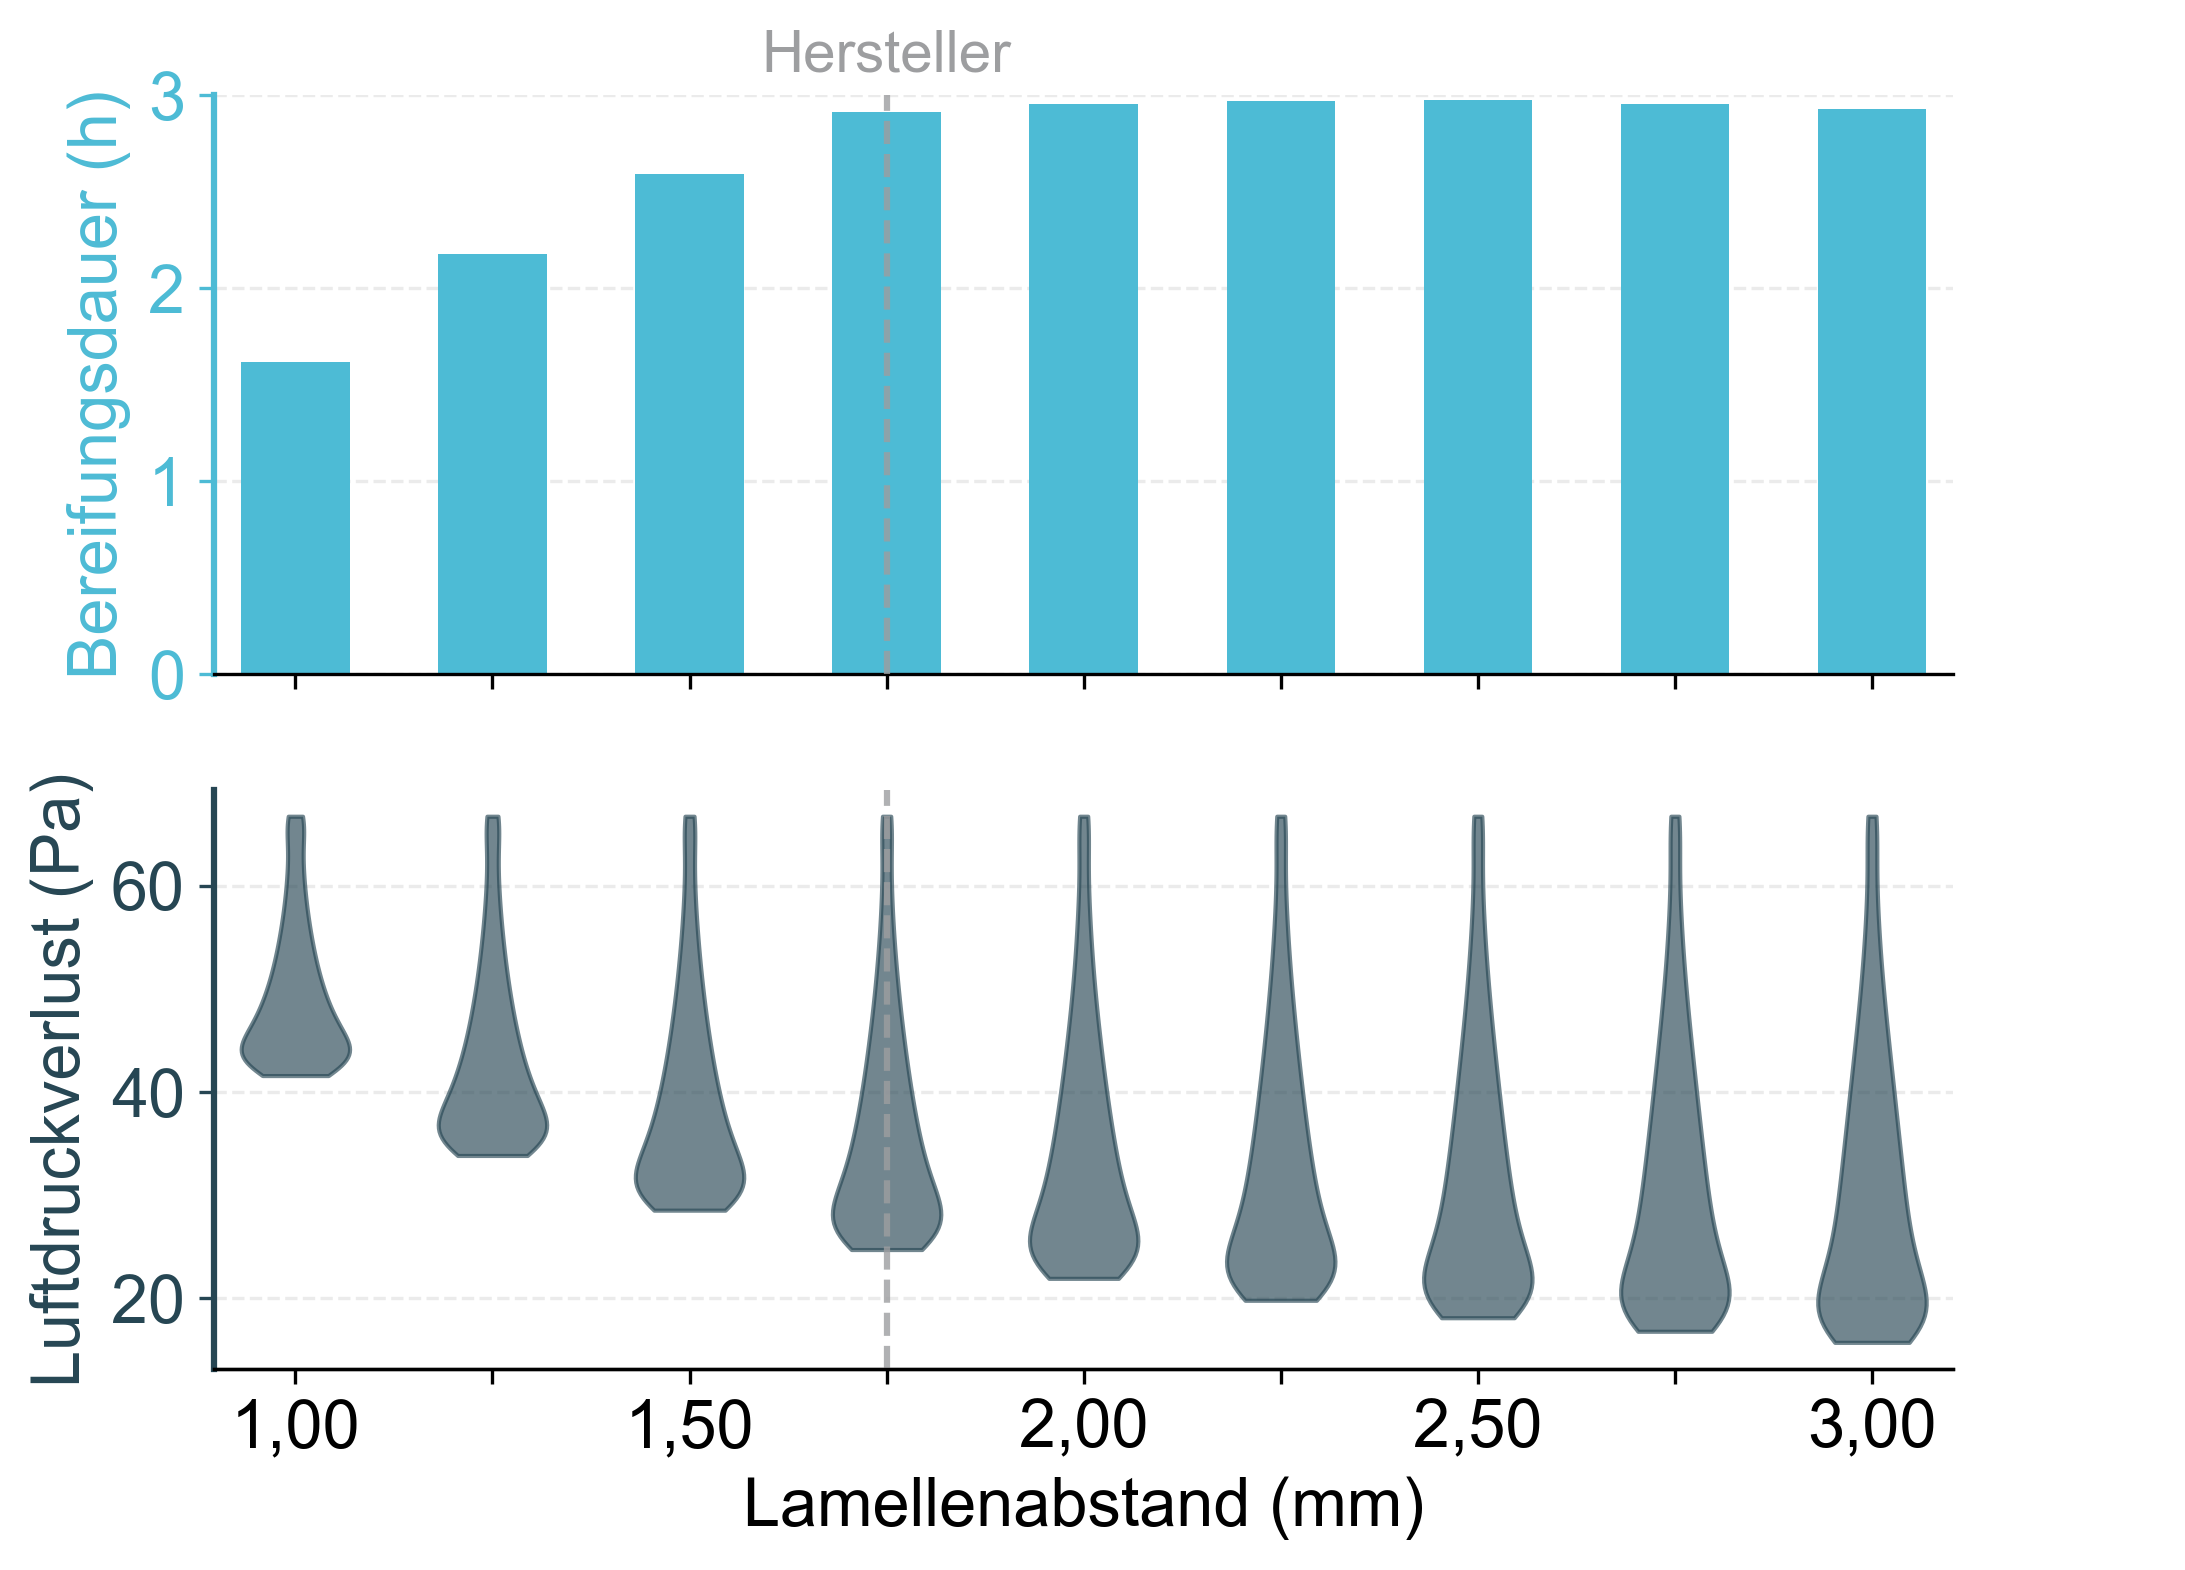

In [26]:
import os
import pickle
import locale
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# =============================================================================
# LOCALE SETTINGS 
# =============================================================================
try:
    locale.setlocale(locale.LC_NUMERIC, "de_DE.UTF-8")
except locale.Error:
    try:
        locale.setlocale(locale.LC_NUMERIC, "de_DE")
    except locale.Error:
        print("Warnung: Deutsches Locale konnte nicht geladen werden. Nutze Fallback.")

# =============================================================================
# GLOBAL PLOT-SETTINGS FOR POWERPOINT
# =============================================================================
def set_plot_style():
    cm_to_inch = 1 / 2.54
    height_cm = 14.0 
    width_cm = 19.0  

    FONT_FAMILY = "Arial"
    FONT_SIZE = 16

    plt.rcParams.update({
        "figure.figsize": (width_cm * cm_to_inch, height_cm * cm_to_inch),
        "figure.dpi": 300,
        "font.family": FONT_FAMILY,
        "font.size": FONT_SIZE,
        "axes.labelsize": FONT_SIZE,
        "legend.fontsize": FONT_SIZE,
        "xtick.labelsize": FONT_SIZE,
        "ytick.labelsize": FONT_SIZE,
        "axes.formatter.use_locale": True,
        "axes.linewidth": 0.8,
        "grid.color": "#D9D9D9",
        "grid.linestyle": "--",
        "grid.alpha": 0.5,
        "legend.frameon": False,
        "savefig.bbox": "tight",
        "savefig.format": "svg"
    })

    return {
        "blue": "#00549F",
        "dark_grey": "#4E4F50",
        "mid_grey": "#9D9EA0",
        "light_grey": "#D9D9D9",
        "abtauen": "#4DBBD5",    
        "luefter": "#F39C12",    
        "verdichter": "#E74C3C",
        "soft_blue": "#264653",   # Dunkles Petrol/Schieferblau (Violinen)
        "soft_orange": "#EF233C"  # Sattes Ocker/Goldgelb (Reifdicke)
    }

def main():
    colors = set_plot_style()
    
    # =============================================================================
    # 1. DATEN LADEN UND EXTRAHIEREN
    # =============================================================================
    filename = "simulation_data/final/06_grid_horst_final.pkl"
    target_app = 'Medium'
    target_pt  = 'A'

    MANUFACTURER_PITCH_MM = 1.75
    ticks_y_time = np.arange(0, 4, 1)

    try:
        with open(filename, "rb") as f:
            all_data = pickle.load(f)
            all_runs_data = all_data["runs_data"]
    except FileNotFoundError:
        print(f"Error: Datei '{filename}' nicht gefunden.")
        return
    
    extracted_data = {}

    for run in all_runs_data:
        if "metadata" not in run or "error" in run:
            continue
            
        meta = run["metadata"]
        context = meta.get("norm_context", {})

        if context.get("application") == target_app and context.get("test_point") == target_pt:
            inputs = meta.get("inputs", {})
            pitch_m = inputs.get("pitch", 0)
            pitch_mm = pitch_m * 1000.0
            
            time_arr = np.array(run.get("time", []), dtype=float)
            dp_air = np.array(run.get("dp_air", []), dtype=float)
            space_m = np.array(run.get("space_between_frost", []), dtype=float)
            
            valid_idx = ~np.isnan(dp_air) & ~np.isnan(space_m)
            time_arr = time_arr[valid_idx]
            dp_air = dp_air[valid_idx]
            space_m = space_m[valid_idx]
            
            if len(dp_air) > 0:
                thickness_mm = (pitch_m - space_m) / 2.0 * 1000.0
                
                extracted_data[pitch_mm] = {
                    "final_time": time_arr[-1],
                    "dp_air_full": dp_air,
                    "final_thickness": thickness_mm[-1]
                }

    if not extracted_data:
        print(f"Keine Daten gefunden.")
        return

    sorted_pitches = sorted(extracted_data.keys())
    x_pitches = np.array(sorted_pitches)
    y_time = np.array([extracted_data[p]["final_time"] for p in sorted_pitches]) / 60.0
    y_thick = np.array([extracted_data[p]["final_thickness"] for p in sorted_pitches])
    violin_dp_data = [extracted_data[p]["dp_air_full"] for p in sorted_pitches]

    bar_width = np.min(np.diff(sorted_pitches)) * 0.55 if len(sorted_pitches) > 1 else 0.3

    # =============================================================================
    # 2. PLOTTING SETUP (2-Panel Layout)
    # =============================================================================
    # hspace etwas großzügiger wegen der großen Schrift
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, gridspec_kw={'hspace': 0.2})
    ax2_twin = ax2.twinx()
    
    color_manuf = colors["mid_grey"]

    # -------------------------------------------------------------------------
    # PANEL 1 (Oben): Bereifungsdauer UNVERÄNDERT aus erstem Skript
    # -------------------------------------------------------------------------
    color_dur = colors["abtauen"] 

    ax1.set_ylabel("Bereifungsdauer (h)", color=color_dur)
    
    # Y-Achse
    ax1.set_yticks(ticks_y_time)
    ax1.set_ylim(min(ticks_y_time), max(ticks_y_time))
    ax1.tick_params(axis='y', colors=color_dur)

    # Styling
    ax1.spines['left'].set_color(color_dur)
    ax1.spines['left'].set_linewidth(1.5)
    ax1.grid(axis='y', linestyle='--', linewidth=0.8, alpha=0.5, zorder=0)
    ax1.set_axisbelow(True)

    # Herstellerlinie (Hintergrund)
    ax1.axvline(x=MANUFACTURER_PITCH_MM, color=color_manuf, linestyle='--', linewidth=1.5, alpha=0.8, zorder=100)
    ax1.text(MANUFACTURER_PITCH_MM, max(ticks_y_time)*1.02, 'Hersteller', color=color_manuf, fontsize=14, 
             ha='center', va='bottom', clip_on=False, zorder=0)

    # Bereifungsdauer (Balken)
    bars_time = ax1.bar(x_pitches, y_time, width=bar_width, color=color_dur, alpha=1.0, zorder=2)

    # -------------------------------------------------------------------------
    # PANEL 2 (Unten): Trade-Off (Druckverlust vs. Reifdicke)
    # -------------------------------------------------------------------------
    color_dp = colors["soft_blue"]
    color_thick = colors["soft_orange"]
    
    # 1. Violine für Druckverlust (Primärachse ax2)
    parts = ax2.violinplot(violin_dp_data, positions=x_pitches, widths=bar_width,
                           showmeans=False, showmedians=False, showextrema=False)
    
    for pc in parts['bodies']:
        pc.set_facecolor(color_dp)
        pc.set_edgecolor(color_dp)
        pc.set_alpha(0.65)  # Etwas transparenter für eine sanftere Optik
        pc.set_zorder(2)

    ax2.set_ylabel("Luftdruckverlust (Pa)", color=color_dp)
    ax2.tick_params(axis='y', colors=color_dp)
    ax2.spines['left'].set_color(color_dp)
    ax2.spines['left'].set_linewidth(1.5)
    
    ax2.grid(axis='y', linestyle='--', linewidth=0.8, alpha=0.5, zorder=0)
    ax2.set_axisbelow(True)
    
    # 2. Kurve für finale Reifdicke (Sekundärachse ax2_twin)
    ax2_twin.plot(x_pitches, y_thick, color=color_thick, linestyle='--', linewidth=2.0, 
                  marker='D', markersize=8, markerfacecolor='white', markeredgewidth=1.5, zorder=5)
    
    ax2_twin.set_ylabel("Finale Reifschichtdicke (mm)", color=color_thick)
    ax2_twin.tick_params(axis='y', colors=color_thick)
    ax2_twin.spines['right'].set_color(color_thick)
    ax2_twin.spines['right'].set_linewidth(1.5)

    ax2_twin.set_yticks([0, 0.5, 1.0])

    # Herstellerlinie auch im unteren Panel durchziehen
    ax2.axvline(x=MANUFACTURER_PITCH_MM, color=color_manuf, linestyle='--', linewidth=1.5, alpha=0.8, zorder=100)

    # -------------------------------------------------------------------------
    # GLOBALE X-ACHSE & SPINES AUFRÄUMEN
    # -------------------------------------------------------------------------
    ax2.set_xlabel("Lamellenabstand (mm)")
    
    pad_x = bar_width * 0.75
    ax2.set_xlim(min(x_pitches) - pad_x, max(x_pitches) + pad_x)

    # 1. Definiere die X-Werte, bei denen explizit eine ZAHL stehen soll:
    zahlen_ticks = [1.0, 1.5, 2.0, 2.5, 3.0] 

    # 2. Generiere die passenden Labels: 
    # Wenn der Wert in der Liste ist, schreibe die Zahl, sonst lasse sie leer ("").
    labels = []
    for p in x_pitches:
        # Wir runden auf 2 Nachkommastellen, um Ungenauigkeiten beim Vergleich zu vermeiden
        if round(p, 2) in zahlen_ticks:
            labels.append(f"{p:.2f}".replace('.', ','))
        else:
            labels.append("")  # Leerer String sorgt für einen Strich OHNE Zahl

    # 3. Wende die Striche (x_pitches) und Beschriftungen (labels) an:
    plt.xticks(x_pitches, labels)

    # Spines aufräumen
    for ax in [ax1, ax2, ax2_twin]:
        ax.spines['top'].set_visible(False)
        if ax != ax2_twin:
            ax.spines['right'].set_visible(False)
            
    # Fix für schwarzen Streifen auf der linken Twin-Achse
    ax2_twin.spines['left'].set_visible(False)

    # =============================================================================
    # 3. FINALER EXPORT (ORIGINAL & OHNE RECHTE ACHSE)
    # =============================================================================
    output_dir = r"J:\Masterarbeit_Nils_Baumeister\02_Schriftliche_Ausarbeitung\Graphiken"
    os.makedirs(output_dir, exist_ok=True)
    
    # --- SPEICHERN 1: Original Plot ---
    path_final = os.path.join(output_dir, "PP_zeit_tradeoff_original.svg")
    plt.savefig(path_final)
    print(f"Gespeichert: {path_final}")

    # --- SPEICHERN 2: Plot ohne rechte Achse (Reifdicke) ---
    # 1. Datenlinie und Marker auf ax2_twin ausblenden
    for line in ax2_twin.get_lines():
        line.set_visible(False)
        
    # 2. Rechte Y-Achse vollkommen transparent machen (Farbe auf 'none' setzen)
    ax2_twin.set_ylabel("Finale Reifschichtdicke (mm)", color='none')
    ax2_twin.tick_params(axis='y', colors='none')
    ax2_twin.spines['right'].set_color('none')

    path_final_no_thick = os.path.join(output_dir, "PP_zeit_tradeoff_ohne_reifdicke.svg")
    plt.savefig(path_final_no_thick)
    print(f"Gespeichert: {path_final_no_thick}")

    plt.show()
    plt.close()

if __name__ == "__main__":
    main()